# Препроцессинг и подбор общих параметров: SAR Oil Spill Segmentation

**Исполнитель:** Никитина Дарья Дмитриевна

Этот ноутбук подбирает параметры, которые затем **фиксируются для всех архитектур** (UNet, UNet++, DeepLabV3+, SegFormer). Это гарантирует честное сравнение: разница в метриках будет объясняться только архитектурой, а не разными условиями обучения.

| Раздел | Что делаем | Результат |
|---|---|---|
| EDA | Смотрим на снимки, гистограммы пикселей, дисбаланс классов | Понимаем природу данных |
| Train/Val сплит | Делим 2570 снимков 80/20 стратифицированно по классу **до нормализации**, иначе будет data leakage | `train_val_split.csv` |
| Размер патча | Сравниваем 256×256 и 512×512 - сколько нефтяных патчей, какой контекст | Фиксируем `PATCH_SIZE` |
| Нормализация | Z-score по каждому каналу, **только по train** | `norm_stats.json` |
| Оверсэмплинг | Сравниваем соотношения нефть:фон 1:1 / 1:2 / 1:3 / без - при дисбалансе 1:19 модель учится говорить везде «фон» | Фиксируем `OVERSAMPLE_RATIO` |
| Аугментации | 5 стратегий × 5 эпох на UNet (ResNet34) - от базовой геометрии до SAR-специфичного шума | Фиксируем `BEST_AUG` |
| Loss-функции | 6 функций × Optuna - у Tversky, Focal, WeightedBCE есть гиперпараметры, сравниваем лучшую версию каждой | Фиксируем `BEST_LOSS` и `BEST_LOSS_PARAMS` |
| Итог | Собираем всё в один файл | `shared_config.json` |

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "rasterio",                    # чтение .tiff файлов
                "albumentations",              # библиотека аугментаций
                "optuna",                      # подбор гиперпараметров
                "tabulate",                    # красивый вывод таблиц
                "segmentation-models-pytorch", #архитектуры сегментации
                "-q"], check=False)
print("Зависимости установлены")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.1 MB/s eta 0:00:00
Зависимости установлены


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, gc, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

import rasterio
from rasterio.windows import Window

import albumentations as A
from albumentations.pytorch import ToTensorV2

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

In [3]:
# Воспроизводимость: seed=42 везде
SEED = 42 
random.seed(SEED); np.random.seed(SEED) # фиксация для Python, NumPy
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED) # фиксация для инициализации весов на CPU, GPU
torch.backends.cudnn.deterministic = True # фиксация для детерменирвоанных алгоритмов свёртки
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED) # фиксация хэширования 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  {torch.cuda.get_device_name(0)}  |  "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Пути к датасетам
BASE = Path("/kaggle/input")
OIL_IMG_DIR     = BASE / "datasets/daryanikitina/sar-oil-spill-part1" / "Oil"
OIL_MASK_DIR    = BASE / "datasets/daryanikitina/sar-oil-spill-part1" / "Mask_oil"
NO_OIL_IMG_DIR  = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "No_oil"
NO_OIL_MASK_DIR = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Mask_no_oil"
LOOK_IMG_DIR    = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Lookalike"
LOOK_MASK_DIR   = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Mask_lookalike"
OUTPUT = Path("/kaggle/working")
OUTPUT.mkdir(parents=True, exist_ok=True)

print("\nПроверка данных:")
for name, p in [("Oil images", OIL_IMG_DIR), ("Oil masks", OIL_MASK_DIR),
                ("No-oil images", NO_OIL_IMG_DIR), ("Lookalike images", LOOK_IMG_DIR),
                ("No-oil masks", NO_OIL_MASK_DIR), ("Lookalike masks", LOOK_MASK_DIR)]:
    n = len(list(p.glob("*.tif"))) if p.exists() else 0
    print(f"  {'Всё загрузилось' if n>0 else 'Не все папки загрузились'}  {name:20s}: {n} файлов")

Устройство: cuda
  Tesla T4  |  15.6 GB

Проверка данных:
  Всё загрузилось  Oil images          : 1200 файлов
  Всё загрузилось  Oil masks           : 1200 файлов
  Всё загрузилось  No-oil images       : 685 файлов
  Всё загрузилось  Lookalike images    : 685 файлов
  Всё загрузилось  No-oil masks        : 685 файлов
  Всё загрузилось  Lookalike masks     : 685 файлов


In [4]:
# Вспомогательные функции загрузки данных
# Window API: читает только нужный прямоугольник файла, не загружая снимок 2048×2048 целиком.

def load_image_full(path):
    """Загружает снимок целиком и транспонирует размерность для удобной работы с PyTorch."""
    with rasterio.open(path) as src:
        return np.transpose(src.read().astype(np.float32), (1,2,0))  # (2,H,W) - > (H,W,2); 2 - число каналов в SAR-снимке

def load_mask_full(path):
    """Загружает маску целиком."""
    with rasterio.open(path) as src:
        return src.read(1).astype(np.uint8) # Маска одноканальная - считываем только первый канал - и содержит только целые числа

def load_patch(img_path, mask_path, row, col, patch_size):
    """Загружает только патч."""
    win = Window(col, row, patch_size, patch_size)
    with rasterio.open(img_path) as src:
        img = src.read(window=win).astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1, window=win).astype(np.uint8)

    # Если rasterio вернул неполный патч у края снимка - дополняю нулями до нужного размера
    _, h, w = img.shape
    if h < patch_size or w < patch_size:
        padded_img  = np.zeros((2, patch_size, patch_size), dtype=np.float32)
        padded_mask = np.zeros((patch_size, patch_size),    dtype=np.uint8)
        padded_img[:, :h, :w]  = img
        padded_mask[:h, :w]    = mask
        img  = padded_img
        mask = padded_mask

    return np.transpose(img, (1, 2, 0)), mask
def save_json(obj, path):
    """Сохраняет словарь в JSON. Вызывается сразу после каждого эксперимента."""
    with open(path, "w") as f:
        json.dump(obj, f, indent=4)
    print(f"  Сохранено: {Path(path).name}")

def load_json(path):
    """Загружает сохранённый результат обратно."""
    with open(path) as f:
        return json.load(f)

---
## Блок 1: EDA

In [5]:
# Инвентаризация: изображения и маски раскиданы по разным папкам, поэтому, чтобы вручную не перебирать папку - создаю единую таблицу, где будут прописаны:
# Путь к снимку, путь к маске, название и класс
def build_inventory():
    records = []
    for cls, img_dir, mask_dir in [
        ("Oil",       OIL_IMG_DIR,    OIL_MASK_DIR),
        ("No_oil",    NO_OIL_IMG_DIR, NO_OIL_MASK_DIR),
        ("Lookalike", LOOK_IMG_DIR,   LOOK_MASK_DIR),
    ]:
        for img_f in sorted(img_dir.glob("*.tif")):
            msk_f = mask_dir / img_f.name
            if msk_f.exists():
                records.append({"image_path":str(img_f),"mask_path":str(msk_f),
                                 "filename":img_f.name,"class":cls})
    return pd.DataFrame(records)

INVENTORY = build_inventory()
print(f"Всего пар: {len(INVENTORY)}")
print(INVENTORY["class"].value_counts().rename("Кол-во").to_frame().to_string())

Всего пар: 2570
           Кол-во
class            
Oil          1200
No_oil        685
Lookalike     685


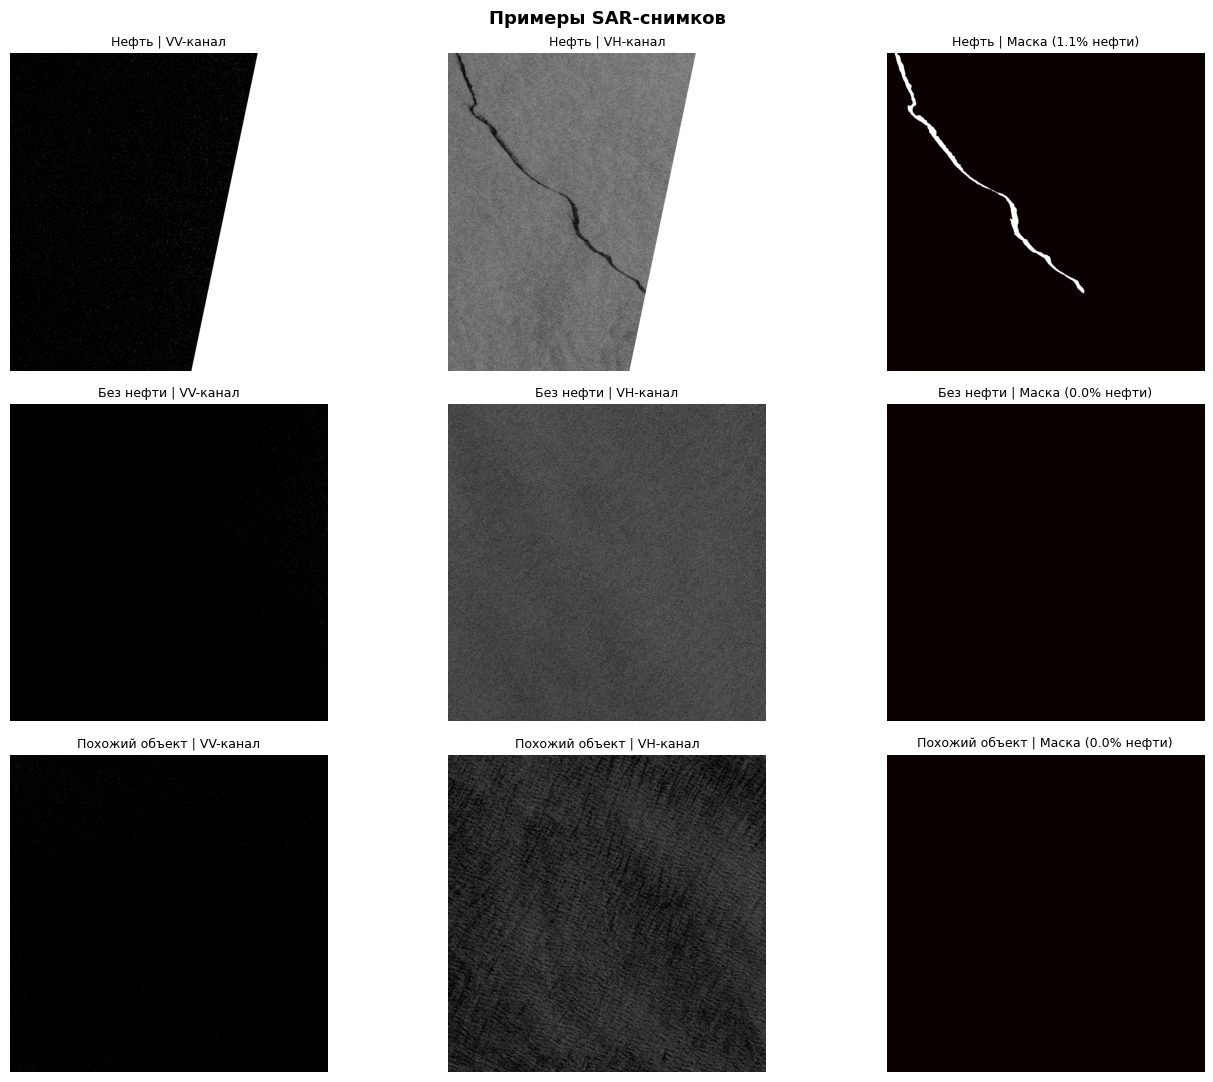

In [7]:
# Примеры снимков и их масок для каждого класса
CLASS_COLORS = {"Oil":"#e74c3c","No_oil":"#3498db","Lookalike":"#2ecc71"}
CLASS_LABEL  = {"Oil":"Нефть","No_oil":"Без нефти","Lookalike":"Похожий объект"}

fig, axes = plt.subplots(3,3,figsize=(14,11))
fig.suptitle("Примеры SAR-снимков", fontsize=13, fontweight="bold")
for ri, cls in enumerate(["Oil","No_oil","Lookalike"]):
    row = INVENTORY[INVENTORY["class"]==cls].sample(1,random_state=SEED+ri).iloc[0]
    img  = load_image_full(row["image_path"])
    mask = load_mask_full(row["mask_path"])
    for ci,(data,title,cmap,vmin,vmax) in enumerate([
        (img[:,:,0], f"{CLASS_LABEL[cls]} | VV-канал", "gray",-30,0), # VV-канал - Радиоволны посылаются вертикально: лучше видит гладкие поверхности -> способен отличить воду от нефти
        (img[:,:,1], f"{CLASS_LABEL[cls]} | VH-канал", "gray",-30,0), # VH-канал - Радиоволны посылаются горизонтально: лучше видит шероховатые структуры ->способен отличить похожие объекты от нефти
        # Значения в SAR-снимках не пиксели, а интенсивность сигнала -> нет цветов, удобнее всего (и привычнее в научном плане) рассматривать в серой палитре
        # Рассматривается диапазон от -30 дБ до 0 - база для SAR-снимков. Если не задать диапазон, то matplotlib будет задавать диапазон под каждый снимок -> ошибочное представление 
        (mask.astype(float),f"{CLASS_LABEL[cls]} | Маска ({mask.mean()*100:.1f}% нефти)","hot",0,1), # 
    ]):
        axes[ri,ci].imshow(data,cmap=cmap,vmin=vmin,vmax=vmax)
        axes[ri,ci].set_title(title,fontsize=9); axes[ri,ci].axis("off")
        for sp in axes[ri,ci].spines.values():
            sp.set_edgecolor(CLASS_COLORS[cls]); sp.set_linewidth(2.5)
plt.tight_layout()
plt.savefig(OUTPUT/"eda_01_samples.png",dpi=120,bbox_inches="tight"); plt.show()

### Вывод: 

Мы смотрим на снимки чтобы понять, как нефть выглядит в SAR-данных и чем отличается от похожих объектов.

**VV-канал** улавливает гладкие поверхности - нефтяная плёнка делает воду ровнее, радар отражается в сторону и пятно выглядит **тёмным**. На снимке нефти видна характерная чёрная полоса на фоне более светлой воды. На снимках без нефти и похожих объектов VV-канал почти однородно тёмный - различить классы по нему сложно.

**VH-канал** улавливает шероховатость поверхности. Здесь видно что *без нефти* и *похожий объект* дают разный серый оттенок: похожий объект темнее. Именно VH помогает отличить нефть от объектов которые тоже выглядят гладко, но по другим причинам (например, спокойная вода или водоросли).

**Маски** подтверждают сильный дисбаланс: на снимке нефти белая полоска занимает очень малую часть изображения, у остальных классов маска полностью чёрная. Это объясняет почему модель без специальных мер будет просто говорить «везде фон» и получать высокую accuracy при **нулевом IoU**.

Oil|ch0:   0%|          | 0/25 [00:00<?, ?it/s]

No_oil|ch0:   0%|          | 0/25 [00:00<?, ?it/s]

Lookalike|ch0:   0%|          | 0/25 [00:00<?, ?it/s]

Oil|ch1:   0%|          | 0/25 [00:00<?, ?it/s]

No_oil|ch1:   0%|          | 0/25 [00:00<?, ?it/s]

Lookalike|ch1:   0%|          | 0/25 [00:00<?, ?it/s]

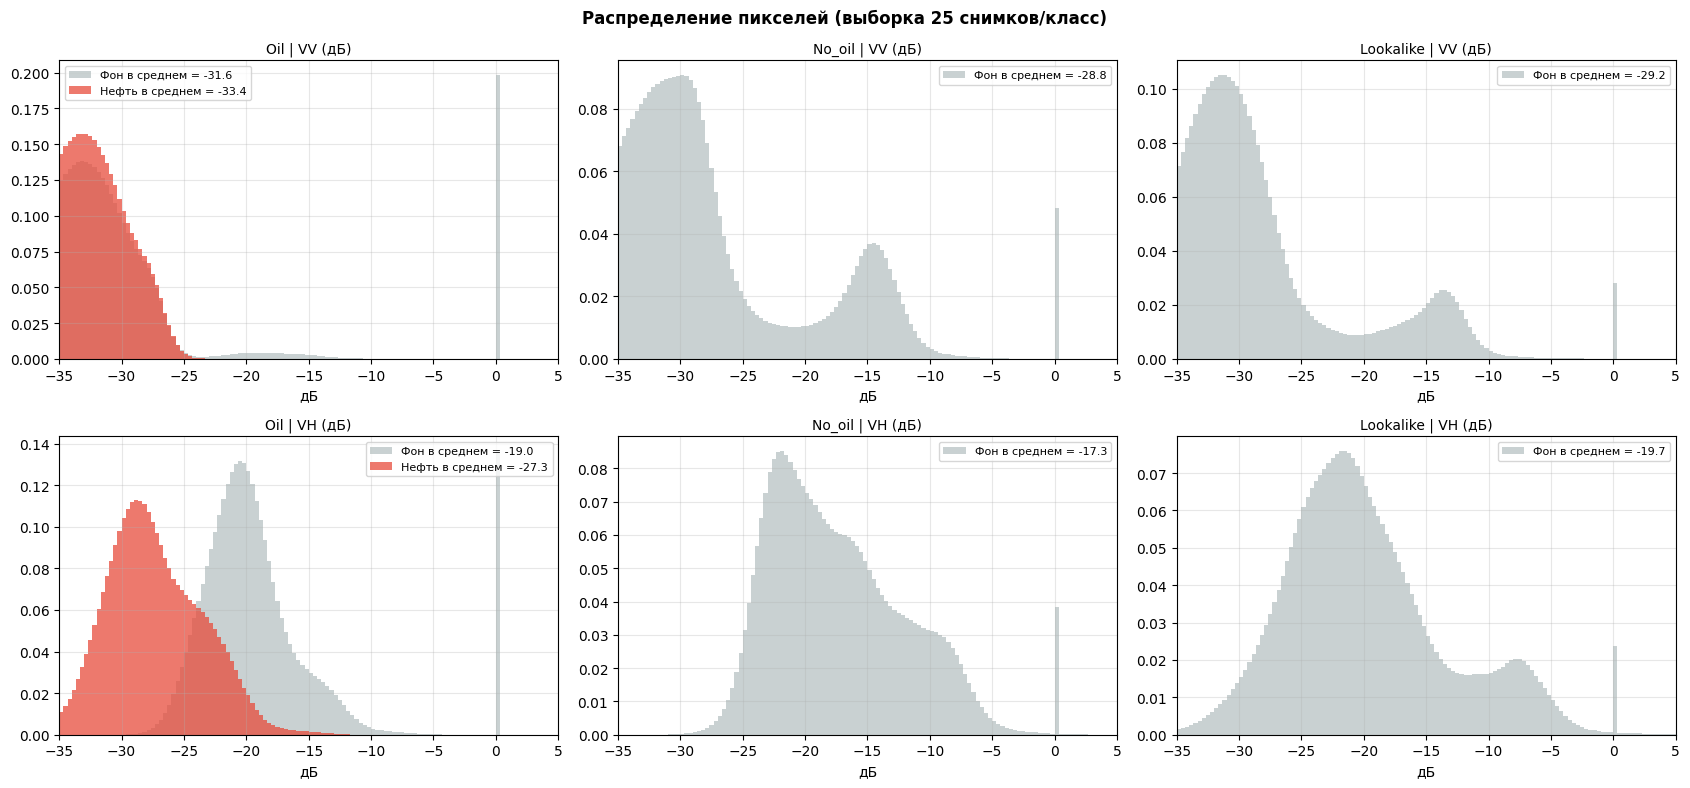

In [7]:
# Гистограммы дБ
SAMPLE_N = 25 # Беру только 25 случайных примеров каждого класса - иначе слишком долго
fig,axes = plt.subplots(2,3,figsize=(17,8))
fig.suptitle(f"Распределение пикселей (выборка {SAMPLE_N} снимков/класс)",fontsize=12,fontweight="bold")
for ch_i,ch_name in enumerate(["VV (дБ)","VH (дБ)"]):
    for cls_i,cls in enumerate(["Oil","No_oil","Lookalike"]):
        ax=axes[ch_i,cls_i]
        subset=INVENTORY[INVENTORY["class"]==cls].sample(
            min(SAMPLE_N,(INVENTORY["class"]==cls).sum()),random_state=SEED)
        bg_pix,oil_pix=[],[]
        for _,r in tqdm(subset.iterrows(),total=len(subset),desc=f"{cls}|ch{ch_i}",leave=False):
            img=load_image_full(r["image_path"])[:,:,ch_i]; mask=load_mask_full(r["mask_path"])
            bg_pix.extend(img[mask==0].ravel().tolist())
            if mask.max()>0: oil_pix.extend(img[mask==1].ravel().tolist())
        bg_arr=np.asarray(bg_pix,dtype=np.float32)
        ax.hist(bg_arr,bins=120,density=True,alpha=0.5,color="#95a5a6",
                label=f"Фон в среднем = {bg_arr.mean():.1f}",range=(-35,5))
        if oil_pix:
            oa=np.asarray(oil_pix,dtype=np.float32)
            ax.hist(oa,bins=120,density=True,alpha=0.75,color=CLASS_COLORS[cls],
                    label=f"Нефть в среднем = {oa.mean():.1f}",range=(-35,5))
        ax.set_title(f"{cls} | {ch_name}",fontsize=10); ax.legend(fontsize=8)
        ax.grid(alpha=0.3); ax.set_xlim(-35,5); ax.set_xlabel("дБ")
plt.tight_layout()
plt.savefig(OUTPUT/"eda_02_histograms.png",dpi=120,bbox_inches="tight"); plt.show()

### Вывод:

По оси X - интенсивность сигнала в дБ, по оси Y - плотность: насколько часто встречается каждое значение.

**VV-канал** плохо разделяет нефть и фон: их распределения почти полностью перекрываются (фон −31.6 дБ, нефть −33.4 дБ - разница всего 2 дБ). У классов No_oil и Lookalike есть небольшой «хвост» левее −35 дБ — это очень тёмные участки, возможно открытая вода или тени.

**VH-канал** - главный канал для различения нефти: пик нефти находится около −30 дБ, а пик фона около −20 дБ, **разница около 10 дБ**. Это означает, что нефтяная плёнка заметно гасит сигнал по сравнению с обычной водной поверхностью. Именно поэтому используются оба канала (2 входных канала в модели) - VH несёт основную различающую информацию, VV добавляет контекст.

**Вывод:** каналы несут разную информацию и оба нужны модели. Использовать только один канал означало бы потерять либо контекст (VV), либо главный сигнал нефти (VH).

Oil fractions:   0%|          | 0/1200 [00:00<?, ?it/s]

╭───────────────────────┬───────────────────────────────────────────╮
│ Медиана доли нефти    │ 1.76%                                     │
│ Среднее               │ 2.98%                                     │
│ Соотношение нефть:фон │ 1 : 70                                    │
│ Accuracy 'везде фон'  │ 99%  - именно поэтому accuracy бесполезна │
╰───────────────────────┴───────────────────────────────────────────╯


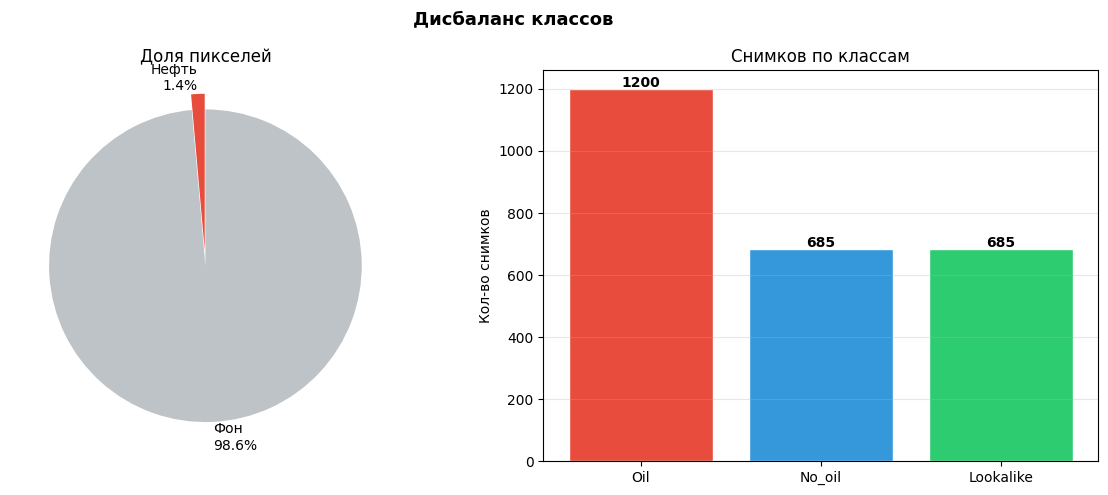

In [6]:
# Дисбаланс классов
oil_df=INVENTORY[INVENTORY["class"]=="Oil"]; fracs=[]
for _,row in tqdm(oil_df.iterrows(),total=len(oil_df),desc="Oil fractions"):
    fracs.append(load_mask_full(row["mask_path"]).mean())
OIL_FRACTIONS=np.array(fracs)

PPX=2048*2048; n_oil=len(INVENTORY[INVENTORY["class"]=="Oil"])
t_oil=int(n_oil*PPX*OIL_FRACTIONS.mean()); t_all=len(INVENTORY)*PPX; t_bg=t_all-t_oil
oil_pct=t_oil/t_all*100

print(tabulate([
    ["Медиана доли нефти",     f"{np.median(OIL_FRACTIONS)*100:.2f}%"],
    ["Среднее",                f"{OIL_FRACTIONS.mean()*100:.2f}%"],
    ["Соотношение нефть:фон",  f"1 : {int(t_bg/t_oil)}"],
    ["Accuracy 'везде фон'",   f"{100-oil_pct:.0f}%  - именно поэтому accuracy бесполезна"],
],tablefmt="rounded_outline"))

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Дисбаланс классов",fontsize=13,fontweight="bold")
ax1.pie([t_oil,t_bg],labels=[f"Нефть\n{oil_pct:.1f}%",f"Фон\n{100-oil_pct:.1f}%"],
        colors=["#e74c3c","#bdc3c7"],explode=(0.1,0),startangle=90)
ax1.set_title("Доля пикселей")
cc=INVENTORY["class"].value_counts()
brs=ax2.bar(cc.index,cc.values,color=["#e74c3c","#3498db","#2ecc71"],edgecolor="white")
for b,v in zip(brs,cc.values): ax2.text(b.get_x()+b.get_width()/2,b.get_height()+5,str(v),ha="center",fontweight="bold")
ax2.set_ylabel("Кол-во снимков"); ax2.grid(axis="y",alpha=0.3); ax2.set_title("Снимков по классам")
plt.tight_layout()
plt.savefig(OUTPUT/"eda_03_imbalance.png",dpi=120,bbox_inches="tight"); plt.show()

### Вывод:

**Дисбаланс критический:** нефть занимает всего **1.4% пикселей** при соотношении нефть:фон = 1:70. Медианная доля нефти на одном снимке - 1.76%, среднее - 2.98% (среднее выше медианы, значит есть несколько снимков с большими пятнами которые тянут среднее вверх).

Это объясняет почему **accuracy бесполезна** как метрика: модель которая всегда предсказывает «везде фон» получает 99% accuracy, ничему не научившись. Поэтому я использую **Oil IoU** - он равен нулю, если модель не нашла ни одного пикселя нефти.

По количеству снимков дисбаланс менее критичный: нефтяных снимков 1200, No_oil и Lookalike по 685. Но это не отменяет проблему на уровне пикселей: даже на нефтяных снимках нефть занимает малую площадь.

Именно поэтому далее я тестирую **оверсэмплинг** нефтяных патчей, чтобы модель видела нефть достаточно часто во время обучения.

---
## Блок 2: Train/Val сплит

Делается **до нормализации** - иначе статистика из val попадёт в train (data leakage).

In [6]:
# Сплит 80/20 + сохранение CSV файла для точной воспроизводимости в дальнейших ноутбуках
CSV_PATH = OUTPUT / "train_val_split.csv"

if CSV_PATH.exists():
    print("Загружаю готовый сплит")
    SPLIT_DF = pd.read_csv(CSV_PATH)
    TRAIN_DF = INVENTORY[INVENTORY["filename"].isin(SPLIT_DF[SPLIT_DF["split"]=="train"]["filename"])].copy()
    VAL_DF   = INVENTORY[INVENTORY["filename"].isin(SPLIT_DF[SPLIT_DF["split"]=="val"]["filename"])].copy()
    TRAIN_DF["split"]="train"; VAL_DF["split"]="val"
else:
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
    train_idx,val_idx = next(splitter.split(np.arange(len(INVENTORY)), INVENTORY["class"].values))
    TRAIN_DF = INVENTORY.iloc[train_idx].copy().reset_index(drop=True)
    VAL_DF   = INVENTORY.iloc[val_idx  ].copy().reset_index(drop=True)
    TRAIN_DF["split"]="train"; VAL_DF["split"]="val"
    SPLIT_DF = pd.concat([TRAIN_DF,VAL_DF],ignore_index=True)
    SPLIT_DF[["filename","class","split"]].to_csv(CSV_PATH,index=False)
    print(f"Сохранено: train_val_split.csv")

print(f"Train: {len(TRAIN_DF)}  |  Val: {len(VAL_DF)}")
cross=SPLIT_DF.groupby(["class","split"]).size().unstack(fill_value=0)
cross["%train"]=(cross["train"]/cross["train"].sum()*100).round(1)
cross["%val"]  =(cross["val"]  /cross["val"].sum()  *100).round(1)
print(cross.to_string())

Сохранено: train_val_split.csv
Train: 2056  |  Val: 514
split      train  val  %train  %val
class                              
Lookalike    548  137    26.7  26.7
No_oil       548  137    26.7  26.7
Oil          960  240    46.7  46.7


---
## Блок 3: Эксперимент с размерами патчей

In [7]:
# Анализ 256×256 vs 512×512
PATCH_EXP_FILE = OUTPUT / "exp_patch_results.json"
IMG_SIZE = 2048

def analyze_patching(df, patch_size, n_sample=200):
    n_per=(IMG_SIZE//patch_size)**2
    sampled=df.groupby("class",group_keys=False).apply(
        lambda g: g.sample(min(n_sample//3,len(g)),random_state=SEED)).reset_index(drop=True)
    n_total=n_oil=0; oil_fracs=[]
    for _,row in tqdm(sampled.iterrows(),total=len(sampled),desc=f"Patch {patch_size}",leave=False):
        with rasterio.open(row["mask_path"]) as src: mask=src.read(1)
        for r in range(0,IMG_SIZE,patch_size):
            for c in range(0,IMG_SIZE,patch_size):
                pm=mask[r:r+patch_size,c:c+patch_size]; n_total+=1
                if pm.max()>0: n_oil+=1; oil_fracs.append(pm.mean())
    est=len(df)*n_per
    return {"patch_size":patch_size,"n_per_img":n_per,"est_total":est,
            "est_oil":int(est*(n_oil/max(n_total,1))),
            "pct_oil":round(n_oil/max(n_total,1)*100,1),
            "mean_oil_frac":round(np.mean(oil_fracs)*100,1) if oil_fracs else 0}

if PATCH_EXP_FILE.exists():
    print("Загружаем результаты эксперимента с патчами...")
    patch_results = load_json(PATCH_EXP_FILE)
    r256 = patch_results["256"]; r512 = patch_results["512"]
else:
    r256 = analyze_patching(TRAIN_DF, 256)
    r512 = analyze_patching(TRAIN_DF, 512)
    save_json({"256":r256,"512":r512}, PATCH_EXP_FILE)

print(tabulate([
    ["Патчей на снимок",               r256["n_per_img"],        r512["n_per_img"]],
    ["Всего train-патчей",             f"{r256['est_total']:,}",  f"{r512['est_total']:,}"],
    ["Нефтяных патчей",                f"{r256['est_oil']:,}",    f"{r512['est_oil']:,}"],
    ["% нефтяных патчей",              f"{r256['pct_oil']}%",     f"{r512['pct_oil']}%"],
    ["Ср. доля нефти в нефт. патчах", f"{r256['mean_oil_frac']}%",f"{r512['mean_oil_frac']}%"],
    ["Контекст (10м/пиксель)",        "2.56×2.56 км",            "5.12×5.12 км"],
],headers=["Метрика","256×256","512×512"],tablefmt="rounded_outline"))

Patch 256:   0%|          | 0/198 [00:00<?, ?it/s]

Patch 512:   0%|          | 0/198 [00:00<?, ?it/s]

  Сохранено: exp_patch_results.json
╭───────────────────────────────┬──────────────┬──────────────╮
│ Метрика                       │ 256×256      │ 512×512      │
├───────────────────────────────┼──────────────┼──────────────┤
│ Патчей на снимок              │ 64           │ 16           │
│ Всего train-патчей            │ 131,584      │ 32,896       │
│ Нефтяных патчей               │ 9,791        │ 4,496        │
│ % нефтяных патчей             │ 7.4%         │ 13.7%        │
│ Ср. доля нефти в нефт. патчах │ 13.7%        │ 7.4%         │
│ Контекст (10м/пиксель)        │ 2.56×2.56 км │ 5.12×5.12 км │
╰───────────────────────────────┴──────────────┴──────────────╯


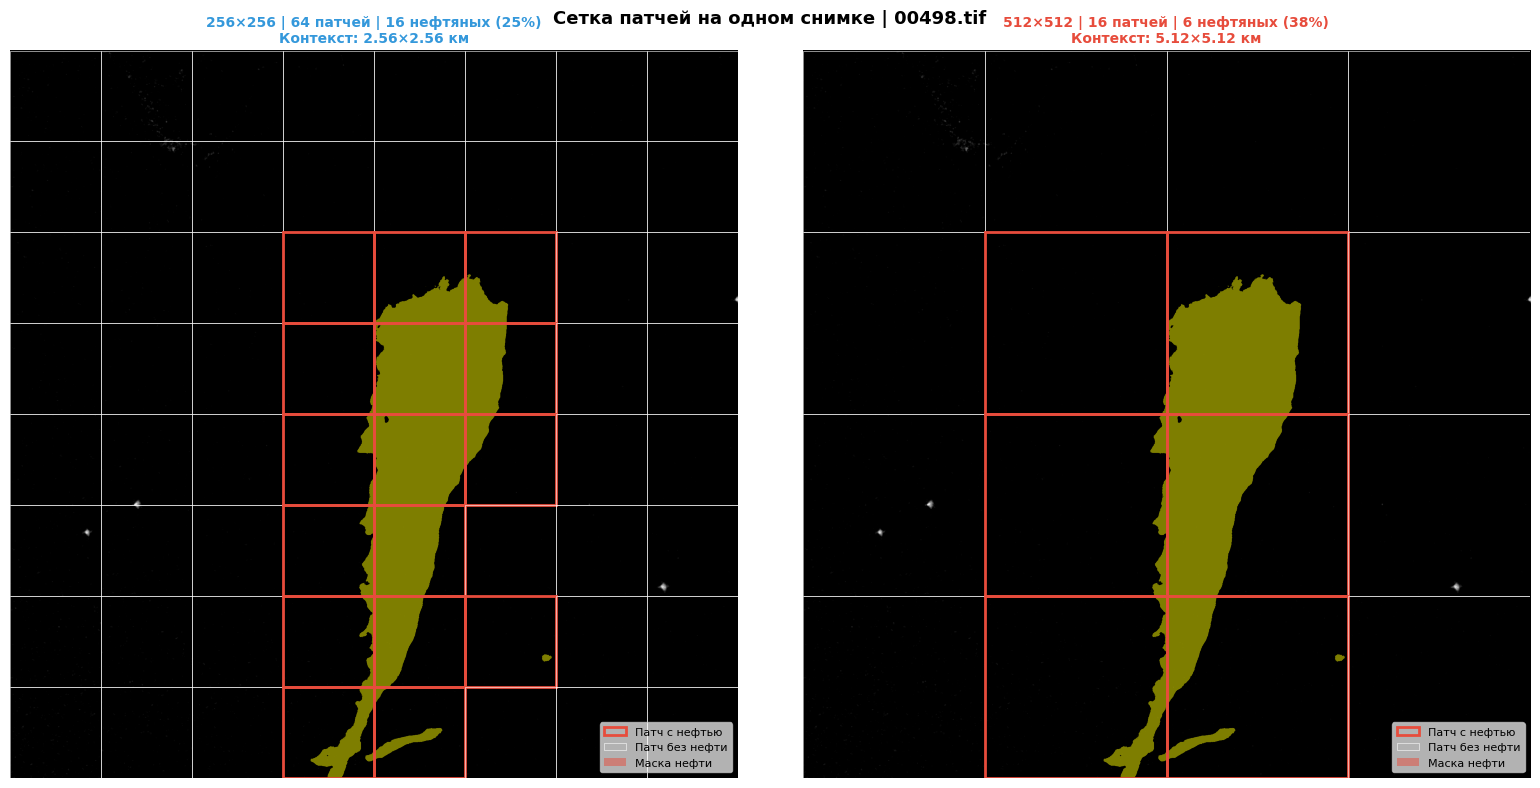

  Сохранено: eda_04_patch_grid.png


In [8]:
# Визуализация сетки патчей - 256×256 vs 512×512
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# Беру Oil-снимок с заметной долей нефти
oil_sample = (
    TRAIN_DF[TRAIN_DF["class"] == "Oil"]
    .assign(frac=lambda df: df["mask_path"].map(
        lambda p: load_mask_full(p).mean()))
    .query("frac > 0.03 and frac < 0.2")  # то есть хотя бы 3-20% нефти, чтобы было что смотреть
    .sample(1, random_state=SEED)
    .iloc[0]
)

img_full  = load_image_full(oil_sample["image_path"])[:, :, 0]  # VV-канал
mask_full = load_mask_full(oil_sample["mask_path"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    f"Сетка патчей на одном снимке | {oil_sample['filename']}",
    fontsize=13, fontweight="bold"
)

for ax, patch_size, color in zip(axes, [256, 512], ["#3498db", "#e74c3c"]):
    # Показываем VV-канал как фон
    ax.imshow(img_full, cmap="gray", vmin=-30, vmax=0)
    # Поверх маска нефти полупрозрачно
    oil_overlay = np.ma.masked_where(mask_full == 0, mask_full)
    ax.imshow(oil_overlay, cmap="autumn", alpha=0.5, vmin=0, vmax=1)

    # Рисую сетку патчей
    n = IMG_SIZE // patch_size
    for i in range(n):
        for j in range(n):
            x, y = j * patch_size, i * patch_size
            pm = mask_full[y:y+patch_size, x:x+patch_size]
            # Рамка: красная, если есть нефть, белая, если нет
            edge = "#e74c3c" if pm.max() > 0 else "white"
            lw   = 2.0       if pm.max() > 0 else 0.4
            rect = mpatches.Rectangle(
                (x, y), patch_size, patch_size,
                linewidth=lw, edgecolor=edge, facecolor="none"
            )
            ax.add_patch(rect)

    n_oil_patches = sum(
        1 for i in range(n) for j in range(n)
        if mask_full[i*patch_size:(i+1)*patch_size,
                     j*patch_size:(j+1)*patch_size].max() > 0
    )
    total_patches = n * n

    ax.set_title(
        f"{patch_size}×{patch_size} | {total_patches} патчей | "
        f"{n_oil_patches} нефтяных ({n_oil_patches/total_patches*100:.0f}%)\n"
        f"Контекст: {patch_size*10/1000:.2f}×{patch_size*10/1000:.2f} км",
        fontsize=10, color=color, fontweight="bold"
    )
    ax.axis("off")

# Легенда
for ax in axes:
    ax.legend(
        handles=[
            mpatches.Patch(edgecolor="#e74c3c", facecolor="none", label="Патч с нефтью", lw=2),
            mpatches.Patch(edgecolor="white",   facecolor="none", label="Патч без нефти", lw=0.4),
            mpatches.Patch(facecolor="#e74c3c", alpha=0.5,        label="Маска нефти"),
        ],
        loc="lower right", fontsize=8, framealpha=0.7
    )

plt.tight_layout()
plt.savefig(OUTPUT / "eda_04_patch_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"  Сохранено: eda_04_patch_grid.png")

### Вывод:


Исходные снимки 2048×2048 пикселей не помещаются в GPU-память целиком, поэтому режу каждый снимок на патчи - маленькие квадратные кусочки - и подаю модели по одному кусочку за раз.

**256×256** даёт 64 патча на снимок и больше нефтяных патчей в абсолютном числе (9,791), но каждый нефтяной патч в среднем содержит только 7.4% нефти - нефтяное пятно размазано по многим мелким кусочкам, часть которых почти пустая. Контекст маленький - 2.56×2.56 км.

**512×512** даёт 16 патчей на снимок, нефтяных патчей меньше (4,496), но каждый содержит в среднем 13.7% нефти - пятно попадает в патч более цельно. Контекст вдвое больше - 5.12×5.12 км, что важно для нефтяных разливов которые имеют протяжённую форму.

**Выбираю 512×512** - модель видит нефтяное пятно в большем контексте и каждый нефтяной патч содержит больше полезного сигнала.

In [30]:
# Финальный выбор
PATCH_SIZE = 512
print(f"PATCH_SIZE = {PATCH_SIZE}  ({PATCH_SIZE*10/1000:.1f}×{PATCH_SIZE*10/1000:.1f} км)")

PATCH_SIZE = 512  (5.1×5.1 км)


---
## Блок 4: Нормализация

In [31]:
# Нормализация приводит все значения пикселей к единому масштабу. Без неё каналы VV и VH имеют разный масштаб:
# модель будет придавать им разный вес не потому что один информативнее, а просто потому что числа в нём больше.

# Z-score нормализация: (x - mean) / std для каждого канала отдельно.
# Считается только по train - val и test не должны влиять на статистику, иначе модель косвенно "видит" данные которых не должна видеть.
# Двухпроходный алгоритм - нельзя загрузить все 2048 снимков в память, поэтому первый проход считает среднее, второй — стандартное отклонение.

# Все участники команды используют эти же значения из norm_stats.jsonб 
# чтобы каждая архитектура получала одинаково подготовленные данные и разница в метриках объяснялась только архитектурой.
NORM_FILE = OUTPUT / "norm_stats.json"

if NORM_FILE.exists():
    print("Загружаю готовую статистику нормализации")
    norm_stats = load_json(NORM_FILE)
else:
    N_CH  = 2                                   # VV и VH
    sums  = np.zeros(N_CH, dtype=np.float64)    # накапливаю сумму пикселей
    count = 0                                   # накапливаю количество пикселей

    # Проход 1: среднее = сумма всех пикселей / их количество
    print("Проход 1/2: вычисление среднего")
    for _, row in tqdm(TRAIN_DF.iterrows(), total=len(TRAIN_DF)):
        with rasterio.open(row["image_path"]) as src:
            img = src.read().astype(np.float64)          # (2, 2048, 2048)
        sums  += img.sum(axis=(1, 2))                    # сумма по H и W
        count += img.shape[1] * img.shape[2]             # 2048 × 2048 пикселей
    means = sums / count

    # Проход 2: std = sqrt(mean((x - mean)^2))
    # Нельзя посчитать за один проход - mean нужен заранее
    sq_diffs = np.zeros(N_CH, dtype=np.float64)
    print("Проход 2/2: вычисление стандартного отклонения")
    for _, row in tqdm(TRAIN_DF.iterrows(), total=len(TRAIN_DF)):
        with rasterio.open(row["image_path"]) as src:
            img = src.read().astype(np.float64)
        for ch in range(N_CH):
            sq_diffs[ch] += ((img[ch] - means[ch]) ** 2).sum()
    stds = np.sqrt(sq_diffs / count)

    norm_stats = {
        "VV_mean": round(float(means[0]), 6),
        "VV_std":  round(float(stds[0]),  6),
        "VH_mean": round(float(means[1]), 6),
        "VH_std":  round(float(stds[1]),  6),
    }
    save_json(norm_stats, NORM_FILE)

print(f"VV: mean = {norm_stats['VV_mean']:.4f} дБ  |  std = {norm_stats['VV_std']:.4f} дБ")
print(f"VH: mean = {norm_stats['VH_mean']:.4f} дБ  |  std = {norm_stats['VH_std']:.4f} дБ")

Загружаю готовую статистику нормализации
VV: mean = -31.3153 дБ  |  std = 7.8787 дБ
VH: mean = -19.7199 дБ  |  std = 6.1687 дБ


In [19]:
# Статистика нормализации посчитана один раз по train-сплиту. Напряму впишу, чтобы не пересчитывать при каждом перезапуске сессии (Kaggle через раз сохраняет файлы сессии)
norm_stats = {
    "VV_mean": -31.3153,
    "VV_std":   7.8787,
    "VH_mean": -19.7199,
    "VH_std":   6.1687,
}
print(f"VV: mean = {norm_stats['VV_mean']:.4f} дБ  |  std = {norm_stats['VV_std']:.4f} дБ")
print(f"VH: mean = {norm_stats['VH_mean']:.4f} дБ  |  std = {norm_stats['VH_std']:.4f} дБ")

VV: mean = -31.3153 дБ  |  std = 7.8787 дБ
VH: mean = -19.7199 дБ  |  std = 6.1687 дБ


---
## Блок 5: Вспомогательный код для экспериментов: UNet, Dataset

In [32]:
class OilSpillDataset(Dataset):
    """
    Загружает патч по координатам из инвентаря через rasterio Window API. Применяет z-score нормализацию и аугментации.
    """
    def __init__(self, patch_df, patch_size, norm_stats, transform=None):
        self.df        = patch_df.reset_index(drop=True)
        self.ps        = patch_size
        self.transform = transform
        self.means = np.array([norm_stats["VV_mean"], norm_stats["VH_mean"]], dtype=np.float32)
        self.stds  = np.array([norm_stats["VV_std"],  norm_stats["VH_std"]],  dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rec = self.df.iloc[idx]
        img, mask = load_patch(
            Path(rec["image_path"]), Path(rec["mask_path"]),
            int(rec["row"]), int(rec["col"]), self.ps
        )
        # Z-score: (x - mean) / std. +1e-8 защита от деления на ноль
        img = (img - self.means) / (self.stds + 1e-8)
        if self.transform:
            aug  = self.transform(image=img, mask=mask.astype(np.float32))
            img  = aug["image"]
            mask = aug["mask"]
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1))  # (H,W,2) -> (2,H,W)
            mask = torch.from_numpy(mask.astype(np.float32))
        return img.float(), mask.float()

In [33]:
def build_model():
    """
    UNet с энкодером ResNet34 из segmentation_models_pytorch. encoder_weights=None - предобучение на ImageNet не используется, так как
    SAR-снимки в дБ принципиально отличаются от RGB-фотографий. Все архитектуры команды используют ResNet34 для честного сравнения.
    """
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=2,   # VV и VH
        classes=1,       # бинарная маска: нефть / фон
    ).to(DEVICE)

In [34]:
def oil_iou(preds, targets, thr=0.5, eps=1e-7):
    """
    IoU только по классу нефти - основная метрика проекта. Модель которая говорит 'везде фон' получает accuracy=95% но Oil IoU=0.
    """
    p = (preds >= thr).float().view(-1)
    t = targets.float().view(-1)
    inter = (p * t).sum()
    union = inter + (p * (1 - t)).sum() + ((1 - p) * t).sum()
    return (inter + eps) / (union + eps)

In [35]:
def get_aug(version):
    """
    5 стратегий аугментаций - от базовой до SAR-специфичной.
    v1: без аугментаций - базовая точка отсчёта
    v2: геометрические (отражения, повороты) - безопасны для SAR, нефтяное пятно не меняет физический смысл при отражении или повороте
    v3: v2 + сдвиг/масштаб/поворот + деформация сетки - имитируют то, что пятно может быть вытянутым, изогнутым, под углом
    v4: v2 + гауссов шум + яркость/контраст - имитируют спекл-шум (зернистость, которая всегда присутствует в радарных снимках из-за природы SAR-сигнала)
    v5: всё вместе + случайные чёрные квадраты - имитируют пропуски сигнала, которые бывают из-за помех или краёв сцены
    """
    # Базовый набор геометрии - используется во всех версиях, кроме v1
    base = [
        A.HorizontalFlip(p=0.5),    # зеркально отражаю патч по горизонтали
        A.VerticalFlip(p=0.5),      # зеркально отражаю патч по вертикали
        A.RandomRotate90(p=0.5),    # поворачиваю патч на 90/180/270 градусов
    ]
    if version == "aug_v1":
        return A.Compose([ToTensorV2()])

    elif version == "aug_v2":
        return A.Compose(base + [ToTensorV2()])

    elif version == "aug_v3":
        return A.Compose(base + [
            A.ShiftScaleRotate(
                shift_limit=0.1,    # сдвигаю патч на до 10% в любую сторону
                scale_limit=0.1,    # масштабирую на 10%
                rotate_limit=45,    # поворачиваю на произвольный угол до 45°
                p=0.5,
                border_mode=0),     # края заполняю нулями: в SAR ноль означает отсутствие сигнала, что честнее, чем зеркалить соседние пиксели
            A.ElasticTransform(     # локально деформирую сетку пикселей:
                alpha=1.0,          # сила смещения пикселей - 1.0 это лёгкое искажение
                sigma=50,           # плавность искажения - 50 даёт плавную волну, не резкие рывки
                alpha_affine=0.0,
                p=0.3),
                ToTensorV2()])

    elif version == "aug_v4":
        return A.Compose(base + [
            A.GaussNoise(
                var_limit=(0.01, 0.05),  # добавляю случайный шум к каждому пикселю - имитирую спекл-шум SAR (зернистость радарного сигнала)
                p=0.5),
            A.RandomBrightnessContrast(
                0.1, 0.1,                # случайно меняю яркость и контраст на 10% - имитирую разные условия съёмки
                p=0.3),
            ToTensorV2()])

    elif version == "aug_v5":
        return A.Compose(base + [
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1,
                               rotate_limit=45, p=0.5, border_mode=0),
            A.ElasticTransform(1.0, 50, 0, p=0.3),
            A.GaussNoise((0.01, 0.05), p=0.5),
            A.RandomBrightnessContrast(0.1, 0.1, p=0.3),
            A.CoarseDropout(
                max_holes=4,        # рисую до 4 случайных чёрных квадратов на патче:
                max_height=32,      # каждый квадрат до 32×32 пикселей
                max_width=32,       # имитирую пропуски сигнала и краевые артефакты SAR
                fill_value=0,
                p=0.2),
            ToTensorV2()])

In [36]:
def make_loaders(train_patches, val_patches, aug_ver, bs=4, nw=0):
    """
    Создаёт два DataLoader: для train и val.
    """
    def worker_init(wid):
        # Каждый worker получает свой seed - иначе все workers дают одинаковую случайность и аугментации повторяются
        np.random.seed(SEED + wid)
        random.seed(SEED + wid)

    # Train: с аугментациями выбранной стратегии
    tds = OilSpillDataset(train_patches, PATCH_SIZE, norm_stats,
                          transform=get_aug(aug_ver))
    
    # Val: только перевод в тензор - никаких аугментаций, иначе метрика нечестная
    vds = OilSpillDataset(val_patches, PATCH_SIZE, norm_stats,
                          transform=A.Compose([ToTensorV2()]))

    tl  = DataLoader(tds, batch_size=bs, shuffle=True, num_workers=nw, pin_memory=False, drop_last=True, worker_init_fn=worker_init)
    vl  = DataLoader(vds, batch_size=bs, shuffle=False, num_workers=nw, pin_memory=False)
    return tl, vl

In [37]:
def run_training(aug_ver, train_patches, val_patches, epochs=10, bs=4, seed=SEED):
    """
    Обучает UNet заданное число эпох с фиксированным BCE loss.
    BCE используется как нейтральный loss для экспериментов с оверсэмплингом и аугментациями, чтобы изолировать влияние одного фактора за раз.
    Возвращает среднее Oil IoU по последним 3 эпохам: устойчивее, чем просто лучший результат, который может быть случайным выбросом.
    """
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed(seed)
    
    model   = build_model()
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss().to(DEVICE)
    tl, vl  = make_loaders(train_patches, val_patches, aug_ver, bs)
    
    iou_history = []
    
    for ep in range(1, epochs + 1):
        
        model.train()
        for imgs, masks in tl:
            # non_blocking=True: CPU не ждёт пока данные переедут на GPU, а сразу готовит следующий батч - небольшое ускорение
            imgs  = imgs.to(DEVICE,  non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            
            opt.zero_grad()
            loss = loss_fn(model(imgs).squeeze(1), masks)
            loss.backward()
            
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            # Явно удаляю батч и граф вычислений сразу после шага. PyTorch не освобождает память автоматически до конца итерации -
            # без удаления все батчи эпохи висят в памяти одновременно -> Kaggle выдаёт ошибку, что пытаюсь занять памяти больше, чем есть
            del imgs, masks, loss

        model.eval()
        
        # Храню только два числа вместо всех предсказаний разом, батч посчитала, добавила к сумме и выбросила
        inter_sum = 0.0
        union_sum = 0.0
        eps = 1e-7
        
        with torch.no_grad():
            for imgs, masks in vl:
                imgs  = imgs.to(DEVICE, non_blocking=True)
                preds = torch.sigmoid(model(imgs).squeeze(1))
                p = (preds >= 0.5).float().view(-1).cpu()
                t = masks.float().view(-1)
                
                inter_sum += (p * t).sum().item()
                union_sum += (p * t).sum().item() + \
                             (p * (1 - t)).sum().item() + \
                             ((1 - p) * t).sum().item()
                
                # Удаляю батч сразу - не жду конца val loop
                del imgs, preds, p, t
        
        iou = (inter_sum + eps) / (union_sum + eps)
        iou_history.append(iou)
        
        # Чищу GPU-кэш после каждой эпохи
        torch.cuda.empty_cache()
        gc.collect()  # то же самое но для CPU
        
        print(f"  Эпоха {ep:02d}/{epochs}  |  Oil IoU = {iou:.4f}")
    
    last3_mean = float(np.mean(iou_history[-3:]))
    print(f"  Среднее последних 3 эпох: {last3_mean:.4f}  |  "
          f"История: {[f'{x:.3f}' for x in iou_history]}")
    
    # Удаляю модель и оптимизатор: без этого следующая стратегия оверсэмплинга запускала бы вторую модель
    # поверх первой и память кончалась бы ещё быстрее 
    
    del model, opt, tl, vl, loss_fn
    torch.cuda.empty_cache()
    gc.collect()
    
    return last3_mean

In [38]:
params_count = sum(p.numel() for p in build_model().parameters())
print(f"UNet (ResNet34) готов. Параметров: {params_count:,}")

UNet (ResNet34) готов. Параметров: 24,433,233


---
## Блок 6: Эксперимент с оверсемплингом

In [39]:
# Перебираю 4 стратегии, обучаю UNet на каждой, выбираю по Oil IoU.

# Почему не Optuna: Optuna эффективна когда пространство поиска большое и непрерывное (например, learning rate от 1e-5 до 1e-1 - миллионы вариантов).
# Здесь всего 4 дискретных варианта - прямой перебор исчерпывающий и честный.

# Аугментация и loss фиксированы на базовых значениях (aug_v1, bce), чтобы изолировать влияние только стратегии оверсэмплинга.

OVERSAMPLE_EXP_FILE = OUTPUT / "exp_oversample_results.json"
STRATEGIES = ["none", "1:1", "1:2", "1:3"]

In [40]:
# Ограничиваю размер выборки для всех стратегий одинаково. При полном train-инвентаре (38 864 патчей) одна эпоха занимает примерно 2 часа:
# четыре стратегии × 5 эпох не укладываются в 12-часовой лимит сессии Kaggle.
# 5 000 патчей это примерно 15 минут на эпоху - все 4 стратегии × 5 эпох ≈ 5 часов.
# Лимит одинаковый и фиксированный для всех стратегий, иначе модели увидят разный объём данных
# и разница в Oil IoU будет объясняться не соотношением нефть:фон, а размером выборки.
MAX_PATCHES = 5_000

def oversample(inv, ratio, seed=SEED):
    """
    Формирует обучающую выборку патчей с заданным соотношением нефть:фон.
    none - все патчи как есть, реальный дисбаланс 17% нефти
    1:1  - равное количество нефтяных и фоновых патчей
    1:2  - на каждый нефтяной патч 2 фоновых
    1:3  - на каждый нефтяной патч 3 фоновых
    Фоновые патчи не дублируются - берётся случайная подвыборка из доступных. Валидация не оверсэмплируется, так как должна отражать реальный дисбаланс данных.
    """
    oil = inv[inv["has_oil"] == 1].copy()
    bg  = inv[inv["has_oil"] == 0].copy()
    
    if ratio == "none":
        result = inv.copy()
    else:
        n_bg = min(len(oil) * {"1:1": 1, "1:2": 2, "1:3": 3}[ratio], len(bg))
        result = pd.concat(
            [oil, bg.sample(n_bg, random_state=seed)], ignore_index=True
        ).sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # Лимит для всех стратегий одинаковый - честное сравнение
    return result.sample(
        min(MAX_PATCHES, len(result)), random_state=seed
    ).reset_index(drop=True)

In [41]:
# Инвентари патчей: создаю отдельные таблицы для tain и val (чтобы валидация точно не утекла в трейн), где лежит информация о каждом патче:
# Его координаты (по столбцам и строкам), есть ли нефть и если есть, то сколько.
# Это необходимо для оверсемплинга, чтобы понимать, что патч с фоном берётся 1 раз, а патч с нефтью - несколько.
TRAIN_INV_FILE = OUTPUT / "train_patch_inventory.csv"
VAL_INV_FILE   = OUTPUT / "val_patch_inventory.csv"

def build_patch_inventory(df, patch_size, desc=""):
    records=[]
    for _,row in tqdm(df.iterrows(),total=len(df),desc=desc):
        with rasterio.open(row["mask_path"]) as src: mask=src.read(1)
        for r in range(0,IMG_SIZE,patch_size):
            for c in range(0,IMG_SIZE,patch_size):
                pm=mask[r:r+patch_size,c:c+patch_size]
                records.append({"image_path":row["image_path"],"mask_path":row["mask_path"],
                                 "row":r,"col":c,"has_oil":int(pm.max()>0),"oil_frac":float(pm.mean())})
    return pd.DataFrame(records)

if TRAIN_INV_FILE.exists() and VAL_INV_FILE.exists():
    print("Загружаю готовые инвентари")
    TRAIN_PATCH_INV = pd.read_csv(TRAIN_INV_FILE)
    VAL_PATCH_INV   = pd.read_csv(VAL_INV_FILE)
else:
    print("Строю инвентарь train")
    TRAIN_PATCH_INV = build_patch_inventory(TRAIN_DF, PATCH_SIZE, "Train")
    TRAIN_PATCH_INV.to_csv(TRAIN_INV_FILE, index=False)
    print("Строю инвентарь val")
    VAL_PATCH_INV = build_patch_inventory(VAL_DF, PATCH_SIZE, "Val")
    VAL_PATCH_INV.to_csv(VAL_INV_FILE, index=False)
    print("Инвентари сохранены")

print(f"Train: {len(TRAIN_PATCH_INV):,} патчей  |  нефтяных: {TRAIN_PATCH_INV['has_oil'].sum():,} ({TRAIN_PATCH_INV['has_oil'].mean()*100:.1f}%)")
print(f"Val:   {len(VAL_PATCH_INV):,} патчей")

Строю инвентарь train


Train:   0%|          | 0/2056 [00:00<?, ?it/s]

Строю инвентарь val


Val:   0%|          | 0/514 [00:00<?, ?it/s]

Инвентари сохранены
Train: 32,896 патчей  |  нефтяных: 5,808 (17.7%)
Val:   8,224 патчей


In [42]:
# Статистика по стратегиям дообучения
print("Состав выборки по стратегиям:")
rows = []
for ratio in STRATEGIES:
    s = oversample(TRAIN_PATCH_INV, ratio)
    rows.append([ratio, f"{len(s):,}", f"{s['has_oil'].sum():,}",
                 f"{len(s) - s['has_oil'].sum():,}", f"{s['has_oil'].mean()*100:.1f}%"])
print(tabulate(rows,
               headers=["Стратегия", "Всего", "Нефтяных", "Фоновых", "% нефти"],
               tablefmt="rounded_outline"))

Состав выборки по стратегиям:
╭─────────────┬─────────┬────────────┬───────────┬───────────╮
│ Стратегия   │ Всего   │ Нефтяных   │ Фоновых   │ % нефти   │
├─────────────┼─────────┼────────────┼───────────┼───────────┤
│ none        │ 5,000   │ 865        │ 4,135     │ 17.3%     │
│ 1:1         │ 5,000   │ 2,529      │ 2,471     │ 50.6%     │
│ 1:2         │ 5,000   │ 1,680      │ 3,320     │ 33.6%     │
│ 1:3         │ 5,000   │ 1,275      │ 3,725     │ 25.5%     │
╰─────────────┴─────────┴────────────┴───────────┴───────────╯


In [ ]:
# Обучение
VAL_PATCHES = VAL_PATCH_INV.copy()   # val без оверсэмплинга

if OVERSAMPLE_EXP_FILE.exists():
    print("\nЗагружаю готовые результаты...")
    oversample_results = load_json(OVERSAMPLE_EXP_FILE)
else:
    oversample_results = {}
    for ratio in STRATEGIES:
        print(f"\nСтратегия: {ratio}")
        train_patches = oversample(TRAIN_PATCH_INV, ratio)
        iou = run_training(
        aug_ver="aug_v1",
        train_patches=train_patches,
        val_patches=VAL_PATCHES,
        epochs=5,
        bs = 4
        )
        oversample_results[ratio] = {"oil_iou": round(iou, 4)}
        print(f"  Итог {ratio}: Oil IoU = {iou:.4f}")
    save_json(oversample_results, OVERSAMPLE_EXP_FILE)


Стратегия: none
  Эпоха 01/5  |  Oil IoU = 0.0516
  Эпоха 02/5  |  Oil IoU = 0.0057
  Эпоха 03/5  |  Oil IoU = 0.0462
  Эпоха 04/5  |  Oil IoU = 0.0203
  Эпоха 05/5  |  Oil IoU = 0.0300
  Среднее последних 3 эпох: 0.0322  |  История: ['0.052', '0.006', '0.046', '0.020', '0.030']
  Итог none: Oil IoU = 0.0322

Стратегия: 1:1


In [22]:
# Сессия упала, продолжаю с места, где всё оборвалось
STRATEGIES_REMAINING = ["1:1", "1:2", "1:3"]

VAL_PATCHES = VAL_PATCH_INV.copy()

# Загружаем что уже есть
if OVERSAMPLE_EXP_FILE.exists():
    oversample_results = load_json(OVERSAMPLE_EXP_FILE)
    print(f"Загружены готовые результаты: {list(oversample_results.keys())}")
else:
    oversample_results = {}

for ratio in STRATEGIES_REMAINING:
    if ratio in oversample_results:
        print(f"Стратегия {ratio} уже есть, пропускаем")
        continue
    print(f"\nСтратегия: {ratio}")
    train_patches = oversample(TRAIN_PATCH_INV, ratio)
    iou = run_training(
        aug_ver="aug_v1",
        train_patches=train_patches,
        val_patches=VAL_PATCHES,
        epochs=5,
        bs=4
    )
    oversample_results[ratio] = {"oil_iou": round(iou, 4)}
    print(f"  Итог {ratio}: Oil IoU = {iou:.4f}")
    # Сохраняю после каждой стратегии
    save_json(oversample_results, OVERSAMPLE_EXP_FILE)


Стратегия: 1:1
  Эпоха 01/5  |  Oil IoU = 0.0953
  Эпоха 02/5  |  Oil IoU = 0.1120
  Эпоха 03/5  |  Oil IoU = 0.1212
  Эпоха 04/5  |  Oil IoU = 0.1106
  Эпоха 05/5  |  Oil IoU = 0.1097
  Среднее последних 3 эпох: 0.1138  |  История: ['0.095', '0.112', '0.121', '0.111', '0.110']
  Итог 1:1: Oil IoU = 0.1138
  Сохранено: exp_oversample_results.json

Стратегия: 1:2
  Эпоха 01/5  |  Oil IoU = 0.0101
  Эпоха 02/5  |  Oil IoU = 0.0716
  Эпоха 03/5  |  Oil IoU = 0.0717
  Эпоха 04/5  |  Oil IoU = 0.0690
  Эпоха 05/5  |  Oil IoU = 0.0598
  Среднее последних 3 эпох: 0.0668  |  История: ['0.010', '0.072', '0.072', '0.069', '0.060']
  Итог 1:2: Oil IoU = 0.0668
  Сохранено: exp_oversample_results.json

Стратегия: 1:3
  Эпоха 01/5  |  Oil IoU = 0.0111
  Эпоха 02/5  |  Oil IoU = 0.0054
  Эпоха 03/5  |  Oil IoU = 0.0058
  Эпоха 04/5  |  Oil IoU = 0.0341
  Эпоха 05/5  |  Oil IoU = 0.0307
  Среднее последних 3 эпох: 0.0236  |  История: ['0.011', '0.005', '0.006', '0.034', '0.031']
  Итог 1:3: Oil IoU 

In [25]:
# Результаты

# Добавляю none из первой сессии вручную
oversample_results["none"] = {"oil_iou": 0.0322}
save_json(oversample_results, OVERSAMPLE_EXP_FILE)


print("\nРезультаты эксперимента с оверсэмплингом:")
result_rows = [[r, f"{v['oil_iou']:.4f}"] for r, v in oversample_results.items()]
print(tabulate(result_rows,
               headers=["Стратегия", "Oil IoU (val)"],
               tablefmt="rounded_outline"))

OVERSAMPLE_RATIO = max(oversample_results, key=lambda r: oversample_results[r]["oil_iou"])
print(f"\nВыбрана стратегия: {OVERSAMPLE_RATIO}  "
      f"(Oil IoU = {oversample_results[OVERSAMPLE_RATIO]['oil_iou']:.4f})")

  Сохранено: exp_oversample_results.json

Результаты эксперимента с оверсэмплингом:
╭─────────────┬─────────────────╮
│ Стратегия   │   Oil IoU (val) │
├─────────────┼─────────────────┤
│ 1:1         │          0.1138 │
│ 1:2         │          0.0668 │
│ 1:3         │          0.0236 │
│ none        │          0.0322 │
╰─────────────┴─────────────────╯

Выбрана стратегия: 1:1  (Oil IoU = 0.1138)


In [26]:
# Финальный TRAIN_PATCHES
TRAIN_PATCHES = oversample(TRAIN_PATCH_INV, OVERSAMPLE_RATIO)
print(f"   Train: {len(TRAIN_PATCHES):,} патчей  ({TRAIN_PATCHES['has_oil'].mean()*100:.1f}% нефти)")
print(f"   Val:   {len(VAL_PATCHES):,} патчей  (без оверсэмплинга)")

   Train: 5,000 патчей  (50.6% нефти)
   Val:   8,224 патчей  (без оверсэмплинга)


### Вывод:

Стратегия **1:1 выигрывает с большим отрывом** - Oil IoU 0.1138 против 0.0668 у ближайшего конкурента. Это не случайный шум: разница в 3.5 раза между 1:1 и none говорит о том что без балансировки модель просто не учится находить нефть.

Интересно, что 1:3 показал результат даже хуже, чем none (0.0236 vs 0.0322): слишком много фона возвращает модель к исходной проблеме дисбаланса.

**Абсолютные значения IoU низкие** (лучший результат 0.1138) - это ожидаемо по нескольким причинам: всего 5 эпох обучения, 5 000 патчей из 38 864 доступных, веса ResNet34 инициализированы случайно без предобучения, и использовался базовый BCE без учёта дисбаланса. На val нефть занимает менее 2% пикселей - модели физически сложно её найти при таких условиях.

Фиксирую `OVERSAMPLE_RATIO = 1:1`. На следующих шагах добавляю аугментации и подбираю loss-функцию - каждый из этих факторов должен дать дополнительный прирост Oil IoU.

---
## Блок 7: Эксперимент с аугментациями

Фиксирую loss=bce_dice. Меняю только аугментацию.

In [21]:
# Восстанавливаю TRAIN_PATCHES после обрыва сессии. Использую зафиксированную стратегию оверсемплинга 1:1.
# MAX_PATCHES=5_000 и seed=42 гарантируют, что выбираются ровно те же патчи, что раньше.

TRAIN_PATCHES = oversample(TRAIN_PATCH_INV, "1:1")
VAL_PATCHES = VAL_PATCH_INV.copy()

In [24]:
# Эксперимент с аугментациями: 5 стратегий × 5 эпох
# Фиксирую: оверсэмплинг=1:1 (TRAIN_PATCHES), loss=BCE, bs=4
# Меняю только аугментацию - изолирую её влияние
AUG_EXP_FILE = OUTPUT / "exp_aug_results.json"
AUG_DESCR = {
    "aug_v1": "Без аугментации (контроль)",
    "aug_v2": "Базовая геометрическая (flip, rotate90)",
    "aug_v3": "Расширенная геометрическая (+ ShiftScale, Elastic)",
    "aug_v4": "Шумовая SAR-специфичная (+ GaussNoise, Brightness)",
    "aug_v5": "Комбинированная (геометрия + шум + CoarseDropout)",
}

aug_results = load_json(AUG_EXP_FILE) if AUG_EXP_FILE.exists() else {}
if aug_results:
    print(f"Загружены результаты для: {list(aug_results.keys())}")

for aug_v in ["aug_v1", "aug_v2", "aug_v3", "aug_v4", "aug_v5"]:
    if aug_v in aug_results:
        print(f"  {aug_v}: уже посчитан  IoU={aug_results[aug_v]:.4f}  (пропускаем)")
        continue
    print(f"\n  {aug_v}: {AUG_DESCR[aug_v]}")
    iou = run_training(
        aug_ver=aug_v,
        train_patches=TRAIN_PATCHES,
        val_patches=VAL_PATCHES,
        epochs=5,
        bs=4
    )
    aug_results[aug_v] = round(iou, 6)
    save_json(aug_results, AUG_EXP_FILE)
    print(f"    Val Oil IoU = {iou:.4f}")

BEST_AUG = max(aug_results, key=aug_results.get)
print(f"\nBEST_AUG = {BEST_AUG}  ({AUG_DESCR[BEST_AUG]})")
aug_rows = [[v, f"{iou:.4f}", "ЛУЧШИЙ" if v == BEST_AUG else "", AUG_DESCR[v]]
            for v, iou in aug_results.items()]
print(tabulate(aug_rows,
               headers=["Версия", "Val Oil IoU", "", "Описание"],
               tablefmt="rounded_outline"))


  aug_v1: Без аугментации (контроль)
  Эпоха 01/5  |  Oil IoU = 0.0953
  Эпоха 02/5  |  Oil IoU = 0.1120
  Эпоха 03/5  |  Oil IoU = 0.1212
  Эпоха 04/5  |  Oil IoU = 0.1106
  Эпоха 05/5  |  Oil IoU = 0.1097
  Среднее последних 3 эпох: 0.1138  |  История: ['0.095', '0.112', '0.121', '0.111', '0.110']
  Сохранено: exp_aug_results.json
    Val Oil IoU = 0.1138

  aug_v2: Базовая геометрическая (flip, rotate90)
  Эпоха 01/5  |  Oil IoU = 0.0843
  Эпоха 02/5  |  Oil IoU = 0.0983
  Эпоха 03/5  |  Oil IoU = 0.1128
  Эпоха 04/5  |  Oil IoU = 0.1032
  Эпоха 05/5  |  Oil IoU = 0.1113
  Среднее последних 3 эпох: 0.1091  |  История: ['0.084', '0.098', '0.113', '0.103', '0.111']
  Сохранено: exp_aug_results.json
    Val Oil IoU = 0.1091

  aug_v3: Расширенная геометрическая (+ ShiftScale, Elastic)


TypeError: 'tuple' object is not callable

In [24]:
# Сессия была прервана
AUG_EXP_FILE = OUTPUT / "exp_aug_results.json"
AUG_DESCR = {
    "aug_v1": "Без аугментации (контроль)",
    "aug_v2": "Базовая геометрическая (flip, rotate90)",
    "aug_v3": "Расширенная геометрическая (+ ShiftScale, Elastic)",
    "aug_v4": "Шумовая SAR-специфичная (+ GaussNoise, Brightness)",
    "aug_v5": "Комбинированная (геометрия + шум + CoarseDropout)",
}

aug_results = load_json(AUG_EXP_FILE) if AUG_EXP_FILE.exists() else {}
if aug_results:
    print(f"Загружены результаты для: {list(aug_results.keys())}")

for aug_v in ["aug_v3", "aug_v4", "aug_v5"]:
    if aug_v in aug_results:
        print(f"  {aug_v}: уже посчитан  IoU={aug_results[aug_v]:.4f}  (пропускаем)")
        continue
    print(f"\n  {aug_v}: {AUG_DESCR[aug_v]}")
    iou = run_training(
        aug_ver=aug_v,
        train_patches=TRAIN_PATCHES,
        val_patches=VAL_PATCHES,
        epochs=5,
        bs=4
    )
    aug_results[aug_v] = round(iou, 6)
    save_json(aug_results, AUG_EXP_FILE)
    print(f"    Val Oil IoU = {iou:.4f}")

BEST_AUG = max(aug_results, key=aug_results.get)
print(f"\nBEST_AUG = {BEST_AUG}  ({AUG_DESCR[BEST_AUG]})")
aug_rows = [[v, f"{iou:.4f}", "ЛУЧШИЙ" if v == BEST_AUG else "", AUG_DESCR[v]]
            for v, iou in aug_results.items()]
print(tabulate(aug_rows,
               headers=["Версия", "Val Oil IoU", "", "Описание"],
               tablefmt="rounded_outline"))


  aug_v3: Расширенная геометрическая (+ ShiftScale, Elastic)
  Эпоха 01/5  |  Oil IoU = 0.0946
  Эпоха 02/5  |  Oil IoU = 0.0878
  Эпоха 03/5  |  Oil IoU = 0.0980
  Эпоха 04/5  |  Oil IoU = 0.0924
  Эпоха 05/5  |  Oil IoU = 0.0945
  Среднее последних 3 эпох: 0.0950  |  История: ['0.095', '0.088', '0.098', '0.092', '0.095']
  Сохранено: exp_aug_results.json
    Val Oil IoU = 0.0950

  aug_v4: Шумовая SAR-специфичная (+ GaussNoise, Brightness)
  Эпоха 01/5  |  Oil IoU = 0.0774
  Эпоха 02/5  |  Oil IoU = 0.0903
  Эпоха 03/5  |  Oil IoU = 0.0869
  Эпоха 04/5  |  Oil IoU = 0.0761
  Эпоха 05/5  |  Oil IoU = 0.0894
  Среднее последних 3 эпох: 0.0842  |  История: ['0.077', '0.090', '0.087', '0.076', '0.089']
  Сохранено: exp_aug_results.json
    Val Oil IoU = 0.0842

  aug_v5: Комбинированная (геометрия + шум + CoarseDropout)
  Эпоха 01/5  |  Oil IoU = 0.0738
  Эпоха 02/5  |  Oil IoU = 0.0592
  Эпоха 03/5  |  Oil IoU = 0.0844
  Эпоха 04/5  |  Oil IoU = 0.0860
  Эпоха 05/5  |  Oil IoU = 0.0742

In [25]:
# Корректная таблица с результатом эксперимента
aug_results = {
    "aug_v1": 0.1138,
    "aug_v2": 0.1091,
    "aug_v3": 0.0950,
    "aug_v4": 0.0842,
    "aug_v5": 0.0815,
}
AUG_DESCR = {
    "aug_v1": "Без аугментации (контроль)",
    "aug_v2": "Базовая геометрическая (flip, rotate90)",
    "aug_v3": "Расширенная геометрическая (+ ShiftScale, Elastic)",
    "aug_v4": "Шумовая SAR-специфичная (+ GaussNoise, Brightness)",
    "aug_v5": "Комбинированная (геометрия + шум + CoarseDropout)",
}

BEST_AUG = max(aug_results, key=aug_results.get)
print(f"BEST_AUG = {BEST_AUG}  ({AUG_DESCR[BEST_AUG]})")

aug_rows = [[v, f"{iou:.4f}", "ЛУЧШИЙ" if v == BEST_AUG else "", AUG_DESCR[v]]
            for v, iou in aug_results.items()]
print(tabulate(aug_rows,
               headers=["Версия", "Val Oil IoU", "", "Описание"],
               tablefmt="rounded_outline"))

BEST_AUG = aug_v1  (Без аугментации (контроль))
╭──────────┬───────────────┬────────┬────────────────────────────────────────────────────╮
│ Версия   │   Val Oil IoU │        │ Описание                                           │
├──────────┼───────────────┼────────┼────────────────────────────────────────────────────┤
│ aug_v1   │        0.1138 │ ЛУЧШИЙ │ Без аугментации (контроль)                         │
│ aug_v2   │        0.1091 │        │ Базовая геометрическая (flip, rotate90)            │
│ aug_v3   │        0.095  │        │ Расширенная геометрическая (+ ShiftScale, Elastic) │
│ aug_v4   │        0.0842 │        │ Шумовая SAR-специфичная (+ GaussNoise, Brightness) │
│ aug_v5   │        0.0815 │        │ Комбинированная (геометрия + шум + CoarseDropout)  │
╰──────────┴───────────────┴────────┴────────────────────────────────────────────────────╯


### Вывод:

Лучший результат показала стратегия **aug_v1 - без аугментаций** (Oil IoU = 0.1138). Геометрические аугментации (aug_v2, aug_v3) дали результат близкий к контролю - разница в пределах 0.02. Шумовые и комбинированные стратегии (aug_v4, aug_v5) показали заметно более низкий IoU.

Это согласуется с природой SAR-данных: нефтяное пятно на радарном снимке определяется прежде всего **физическими свойствами сигнала** (ослабление в VH-канале), а не формой или текстурой. Геометрические преобразования не несут новой информации о физике явления, а шумовые аугментации - GaussNoise и CoarseDropout - частично маскируют именно тот слабый сигнал нефти который модель должна научиться распознавать.

**Фиксирую BEST_AUG = aug_v1.** Все четыре архитектуры в рамках проекта будут обучаться без аугментаций - это гарантирует, что разница в метриках объясняется архитектурой, а не условиями обучения.

---
## Блок 8: Эксперимент с loss-функциями

**Почему Optuna, а не просто дефолтные параметры:**

| Loss | Гиперпараметры |
|---|---|
| BCE | нет |
| WeightedBCE | `pos_weight` - насколько сильно штрафовать нефть |
| Dice | нет значимых |
| BCEDice | `bce_weight` - баланс между BCE и Dice; `pos_weight` |
| Tversky | `alpha` - насколько сильно штрафовать пропуск нефти |
| Focal | `alpha` - общий вес; `gamma` - насколько игнорировать лёгкие примеры |

Сравнивать BCE с дефолтным Tversky(0.7, 0.3) нечестно, если оптимальный Tversky может быть (0.8, 0.2). Беру **лучшую версию каждого loss** и сравниваю их.

**Для каждого loss: 5 trials Optuna × 10 эпох. MedianPruner после эпохи 5.** Результаты сохраняются после каждого trial.


In [43]:
# Восстанавливаю переменные после перезапуска сессии
PATCH_SIZE = 512
OVERSAMPLE_RATIO = "1:1"
BEST_AUG = "aug_v1"

# Загружаю патчи - те же 5 000, что и в предыдущих экспериментах
TRAIN_PATCHES = oversample(TRAIN_PATCH_INV, OVERSAMPLE_RATIO)
VAL_PATCHES   = VAL_PATCH_INV.copy()

In [44]:
# Эксперимент с loss-функциями: 6 функций × Optuna (5 trials × 5 эпох)
# Фиксирую: оверсэмплинг=1:1, аугментация=!!!, bs=4
# Меняю только loss - изолирую её влияние на Oil IoU

def build_loss(loss_name, params):
    """Собирает loss-функцию по названию и параметрам из Optuna."""
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss().to(DEVICE)

    elif loss_name == "weighted_bce":
        # pos_weight говорит модели: ошибка на нефти в N раз хуже чем на фоне
        pw = torch.tensor([params["pos_weight"]], dtype=torch.float32).to(DEVICE)
        return nn.BCEWithLogitsLoss(pos_weight=pw).to(DEVICE)

    elif loss_name == "dice":
        # Dice считает перекрытие предсказанной и реальной маски - устойчив к дисбалансу
        return smp.losses.DiceLoss(mode="binary").to(DEVICE)

    elif loss_name == "bce_dice":
        # Комбинация: BCE следит за каждым пикселем, Dice - за формой пятна целиком
        bce_w = params["bce_weight"]
        pw    = torch.tensor([params["pos_weight"]], dtype=torch.float32).to(DEVICE)
        bce   = nn.BCEWithLogitsLoss(pos_weight=pw).to(DEVICE)
        dice  = smp.losses.DiceLoss(mode="binary").to(DEVICE)
        class CombinedLoss(nn.Module):
            def forward(self, pred, target):
                return bce_w * bce(pred, target) + (1 - bce_w) * dice(pred, target)
        return CombinedLoss().to(DEVICE)

    elif loss_name == "tversky":
        # Tversky - обобщение Dice: alpha штрафует за пропуск нефти (FN), beta=1-alpha штрафует за ложную тревогу (FP), alpha>0.5 -> пропуск хуже
        a = params["alpha"]
        return smp.losses.TverskyLoss(mode="binary", alpha=a, beta=1-a).to(DEVICE)

    elif loss_name == "focal":
        # Focal снижает вес лёгких примеров (уверенный фон) и фокусируется на сложных. gamma=0 -> обычная BCE, gamma=2 -> стандартный Focal
        return smp.losses.FocalLoss(
            mode="binary",
            alpha=params["alpha"],
            gamma=params["gamma"]
        ).to(DEVICE)

In [45]:
def run_training_with_loss(loss_fn, train_patches, val_patches, epochs=5, bs=4, seed=SEED):
    """
    Обучает UNet с заданной loss-функцией.
    Аугментация и оверсэмплинг фиксированы - меняется только loss.
    """
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed(seed)

    model = build_model()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    tl, vl = make_loaders(train_patches, val_patches, BEST_AUG, bs)

    iou_history = []

    for ep in range(1, epochs + 1):
        model.train()
        for imgs, masks in tl:
            imgs  = imgs.to(DEVICE,  non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            loss = loss_fn(model(imgs).squeeze(1), masks)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            del imgs, masks, loss

        model.eval()
        inter_sum, union_sum = 0.0, 0.0
        eps = 1e-7
        with torch.no_grad():
            for imgs, masks in vl:
                imgs  = imgs.to(DEVICE, non_blocking=True)
                preds = torch.sigmoid(model(imgs).squeeze(1))
                p = (preds >= 0.5).float().view(-1).cpu()
                t = masks.float().view(-1)
                inter_sum += (p * t).sum().item()
                union_sum += (p * t).sum().item() + \
                             (p * (1 - t)).sum().item() + \
                             ((1 - p) * t).sum().item()
                del imgs, preds, p, t

        iou = (inter_sum + eps) / (union_sum + eps)
        iou_history.append(iou)
        torch.cuda.empty_cache()
        gc.collect()
        print(f"    Эпоха {ep:02d}/{epochs}  |  Oil IoU = {iou:.4f}")

    del model, opt, tl, vl
    torch.cuda.empty_cache()
    gc.collect()

    # Среднее последних 3 эпох - устойчивее, чем просто лучший результат
    return float(np.mean(iou_history[-3:]))

In [46]:
# Пространства поиска гиперпараметров для каждого loss
def loss_search_space(trial, loss_name):
    params = {}
    if loss_name == "weighted_bce":
        params["pos_weight"] = trial.suggest_float("pos_weight", 5.0, 35.0)
        # pos_weight - во сколько раз ошибка на нефти хуже, чем ошибка на фоне.
        # Теоретически оптимум = 95/5 = 19 (соотношение классов), но реальный оптимум зависит от данных, поэтому ищу в диапазоне 5–35.
        # Ниже 5 - модель почти не штрафуется за пропуск нефти.
        # Выше 35 - модель начинает видеть нефть везде (много ложных тревог).

    elif loss_name == "bce_dice":
        params["bce_weight"] = trial.suggest_float("bce_weight", 0.2, 0.8)
        # bce_weight - доля BCE в итоговом loss, остаток (1 - bce_weight) идёт на Dice.
        # BCE следит за каждым пикселем отдельно, Dice - за формой пятна целиком.
        # Диапазон 0.2-0.8: меньше 0.2 означает почти чистый Dice, больше 0.8 - почти чистый BCE, смысл комбинации теряется.

        params["pos_weight"] = trial.suggest_float("pos_weight", 5.0, 35.0)
        # pos_weight здесь применяется только к части BCE.

    elif loss_name == "tversky":
        params["alpha"] = trial.suggest_float("alpha", 0.5, 0.9)
        # alpha - штраф за пропущенную нефть (FN).
        # beta = 1 - alpha - штраф за ложную тревогу (FP).
        # alpha > 0.5 означает: пропустить нефть хуже, чем ошибочно её найти - это правильно для задачи обнаружения разливов.
        # Диапазон 0.5-0.9: ниже 0.5 - Tversky превращается в обычный Dice,
        # выше 0.9 - модель будет видеть нефть везде лишь бы не пропустить.

    elif loss_name == "focal":
        params["alpha"] = trial.suggest_float("alpha", 0.1, 0.5)
        # alpha - базовый вес класса нефти в Focal Loss.
        # Диапазон 0.1-0.5: значения выше 0.5 обычно не используются в Focal,
        # так как gamma уже берёт на себя балансировку сложных примеров.

        params["gamma"] = trial.suggest_float("gamma", 0.5, 4.0)
        # gamma - насколько сильно подавлять лёгкие примеры (уверенный фон).
        # gamma=0 -> обычная BCE без фокусировки.
        # gamma=2 -> стандартный Focal.
        # gamma>2 -> модель почти игнорирует фон и фокусируется только на сложных пикселях.
        # Диапазон 0.5-4.0 покрывает от слабой до очень агрессивной фокусировки.

    # bce и dice — без гиперпараметров, params остаётся пустым словарём, Optuna запустит для них ровно 1 trial
    return params

LOSS_DESCR = {
    "bce":          "Стандартная BCE - контроль",
    "weighted_bce": "BCE с весом для нефти  [pos_weight]",
    "dice":         "Dice Loss - перекрытие областей",
    "bce_dice":     "BCE + Dice  [bce_weight, pos_weight]",
    "tversky":      "Tversky - штраф за пропуск нефти  [alpha]",
    "focal":        "Focal - акцент на сложных пикселях  [alpha, gamma]",
}
LOSSES_ORDER = ["bce", "weighted_bce", "dice", "bce_dice", "tversky", "focal"]

# Для loss без гиперпараметров (bce, dice) нечего подбирать - 1 trial
N_TRIALS_WITH_PARAMS    = 5
N_TRIALS_WITHOUT_PARAMS = 1

In [ ]:
# Запуск Optuna для каждой loss
LOSS_EXP_FILE = OUTPUT / "exp_loss_results.json"
loss_results  = {}

for loss_name in LOSSES_ORDER:
    print(f"\n{'─'*55}")
    print(f"  Loss: {loss_name}  —  {LOSS_DESCR[loss_name]}")
    print(f"{'─'*55}")

    has_params = loss_name in ("weighted_bce", "bce_dice", "tversky", "focal")
    n_trials   = N_TRIALS_WITH_PARAMS if has_params else N_TRIALS_WITHOUT_PARAMS

    trial_cache = []  # результаты trials этого loss

    def objective(trial):
        params  = loss_search_space(trial, loss_name)
        loss_fn = build_loss(loss_name, params)
        # Разный seed для каждого trial, чтобы trials не были идентичными
        iou = run_training_with_loss(loss_fn, TRAIN_PATCHES, VAL_PATCHES,
                                     epochs=5, seed=SEED + trial.number)
        trial_cache.append({"trial": trial.number, "params": params, "iou": round(iou, 6)})
        print(f"  Trial {trial.number}  |  params={params}  |  IoU={iou:.4f}")
        return iou

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=3),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = max(trial_cache, key=lambda x: x["iou"])
    loss_results[loss_name] = {
        "best_iou":    best["iou"],
        "best_params": best["params"],
        "all_trials":  trial_cache,
    }
    print(f"\n  Лучший IoU={best['iou']:.4f}  params={best['params']}")

# Сохраняю итог всего эксперимента одним файлом
save_json(loss_results, LOSS_EXP_FILE)


───────────────────────────────────────────────────────
  Loss: bce  —  Стандартная BCE - контроль
───────────────────────────────────────────────────────
    Эпоха 01/5  |  Oil IoU = 0.0953
    Эпоха 02/5  |  Oil IoU = 0.1120
    Эпоха 03/5  |  Oil IoU = 0.1212
    Эпоха 04/5  |  Oil IoU = 0.1106
    Эпоха 05/5  |  Oil IoU = 0.1097
  Trial 0  |  params={}  |  IoU=0.1138

  Лучший IoU=0.1138  params={}

───────────────────────────────────────────────────────
  Loss: weighted_bce  —  BCE с весом для нефти  [pos_weight]
───────────────────────────────────────────────────────
    Эпоха 01/5  |  Oil IoU = 0.1237
    Эпоха 02/5  |  Oil IoU = 0.1186
    Эпоха 03/5  |  Oil IoU = 0.0689
    Эпоха 04/5  |  Oil IoU = 0.1335
    Эпоха 05/5  |  Oil IoU = 0.1265
  Trial 0  |  params={'pos_weight': 16.236203565420873}  |  IoU=0.1096


In [26]:
# bce и weighted_bce уже посчитаны - вношу вручную
loss_results = {
    "bce": {
        "best_iou": 0.1138,
        "best_params": {},
        "all_trials": [{"trial": 0, "params": {}, "iou": 0.1138}]
    },
    "weighted_bce": {
        "best_iou": 0.1096,
        "best_params": {"pos_weight": 16.236203565420873},
        "all_trials": [{"trial": 0, "params": {"pos_weight": 16.236203565420873}, "iou": 0.1096}]
    },
}

# Считаю только оставшиеся
for loss_name in ["dice", "bce_dice", "tversky", "focal"]:
    print(f"\n{'─'*55}")
    print(f"  Loss: {loss_name}  —  {LOSS_DESCR[loss_name]}")
    print(f"{'─'*55}")

    has_params = loss_name in ("weighted_bce", "bce_dice", "tversky", "focal")
    n_trials   = N_TRIALS_WITH_PARAMS if has_params else N_TRIALS_WITHOUT_PARAMS

    trial_cache = []

    def objective(trial):
        params  = loss_search_space(trial, loss_name)
        loss_fn = build_loss(loss_name, params)
        iou = run_training_with_loss(loss_fn, TRAIN_PATCHES, VAL_PATCHES,
                                     epochs=5, seed=SEED + trial.number)
        trial_cache.append({"trial": trial.number, "params": params, "iou": round(iou, 6)})
        print(f"  Trial {trial.number}  |  params={params}  |  IoU={iou:.4f}")
        return iou

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=3),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = max(trial_cache, key=lambda x: x["iou"])
    loss_results[loss_name] = {
        "best_iou":    best["iou"],
        "best_params": best["params"],
        "all_trials":  trial_cache,
    }
    print(f"\n  Лучший IoU={best['iou']:.4f}  params={best['params']}")

save_json(loss_results, LOSS_EXP_FILE)


───────────────────────────────────────────────────────
  Loss: dice  —  Dice Loss - перекрытие областей
───────────────────────────────────────────────────────
    Эпоха 01/5  |  Oil IoU = 0.1048
    Эпоха 02/5  |  Oil IoU = 0.1089
    Эпоха 03/5  |  Oil IoU = 0.1141
    Эпоха 04/5  |  Oil IoU = 0.1090
    Эпоха 05/5  |  Oil IoU = 0.1385
  Trial 0  |  params={}  |  IoU=0.1205

  Лучший IoU=0.1205  params={}

───────────────────────────────────────────────────────
  Loss: bce_dice  —  BCE + Dice  [bce_weight, pos_weight]
───────────────────────────────────────────────────────
    Эпоха 01/5  |  Oil IoU = 0.1312
    Эпоха 02/5  |  Oil IoU = 0.1202
    Эпоха 03/5  |  Oil IoU = 0.1359
    Эпоха 04/5  |  Oil IoU = 0.1348
    Эпоха 05/5  |  Oil IoU = 0.1418
  Trial 0  |  params={'bce_weight': 0.42472407130841755, 'pos_weight': 33.52142919229749}  |  IoU=0.1375
    Эпоха 01/5  |  Oil IoU = 0.0477
    Эпоха 02/5  |  Oil IoU = 0.1336
    Эпоха 03/5  |  Oil IoU = 0.1454
    Эпоха 04/5  |  Oil 

[W 2026-06-11 22:34:37,655] Trial 0 failed with parameters: {'alpha': 0.649816047538945} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_58/3980883502.py", line 29, in objective
    iou = run_training_with_loss(loss_fn, TRAIN_PATCHES, VAL_PATCHES,
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_58/2107552352.py", line 31, in run_training_with_loss
    for imgs, masks in vl:
                       ^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 801, in _next_data
    data = self._dataset_fetcher.fetch(index)  # may ra

KeyboardInterrupt: 

In [47]:
# bce, weighted_bce, dice, bce_dice уже посчитаны - вношу вручную
loss_results = {
    "bce": {
        "best_iou": 0.1138,
        "best_params": {},
        "all_trials": [{"trial": 0, "params": {}, "iou": 0.1138}]
    },
    "weighted_bce": {
        "best_iou": 0.1096,
        "best_params": {"pos_weight": 16.236203565420873},
        "all_trials": [{"trial": 0, "params": {"pos_weight": 16.236203565420873}, "iou": 0.1096}]
    },
    "dice": {
        "best_iou": 0.1205,
        "best_params": {},
        "all_trials": [{"trial": 0, "params": {}, "iou": 0.1205}]
    },
    "bce_dice": {
        "best_iou": 0.1475,
        "best_params": {"bce_weight": 0.6391963650868431, "pos_weight": 22.959754525911098},
        "all_trials": [
            {"trial": 0, "params": {"bce_weight": 0.42472407130841755, "pos_weight": 33.52142919229749}, "iou": 0.1375},
            {"trial": 1, "params": {"bce_weight": 0.6391963650868431, "pos_weight": 22.959754525911098}, "iou": 0.1475},
            {"trial": 2, "params": {"bce_weight": 0.29361118426546196, "pos_weight": 9.67983561008608}, "iou": 0.1267},
            {"trial": 3, "params": {"bce_weight": 0.23485016730091968, "pos_weight": 30.985284373248057}, "iou": 0.1433},
            {"trial": 4, "params": {"bce_weight": 0.5606690070459254, "pos_weight": 26.242177333881365}, "iou": 0.1474},
        ]
    },
}

# Считаю только оставшиеся
for loss_name in ["focal"]:
    print(f"\n{'─'*55}")
    print(f"  Loss: {loss_name}  —  {LOSS_DESCR[loss_name]}")
    print(f"{'─'*55}")

    n_trials    = N_TRIALS_WITH_PARAMS
    trial_cache = []

    def objective(trial):
        params  = loss_search_space(trial, loss_name)
        loss_fn = build_loss(loss_name, params)
        iou = run_training_with_loss(loss_fn, TRAIN_PATCHES, VAL_PATCHES,
                                     epochs=5, seed=SEED + trial.number)
        trial_cache.append({"trial": trial.number, "params": params, "iou": round(iou, 6)})
        print(f"  Trial {trial.number}  |  params={params}  |  IoU={iou:.4f}")
        return iou

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=3),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = max(trial_cache, key=lambda x: x["iou"])
    loss_results[loss_name] = {
        "best_iou":    best["iou"],
        "best_params": best["params"],
        "all_trials":  trial_cache,
    }
    print(f"\n  Лучший IoU={best['iou']:.4f}  params={best['params']}")

save_json(loss_results, LOSS_EXP_FILE)


───────────────────────────────────────────────────────
  Loss: focal  —  Focal - акцент на сложных пикселях  [alpha, gamma]
───────────────────────────────────────────────────────
    Эпоха 01/5  |  Oil IoU = 0.0518
    Эпоха 02/5  |  Oil IoU = 0.0221
    Эпоха 03/5  |  Oil IoU = 0.0026
    Эпоха 04/5  |  Oil IoU = 0.0348
    Эпоха 05/5  |  Oil IoU = 0.0756
  Trial 0  |  params={'alpha': 0.249816047538945, 'gamma': 3.827500072434707}  |  IoU=0.0377
    Эпоха 01/5  |  Oil IoU = 0.0176
    Эпоха 02/5  |  Oil IoU = 0.0336
    Эпоха 03/5  |  Oil IoU = 0.0069
    Эпоха 04/5  |  Oil IoU = 0.0746
    Эпоха 05/5  |  Oil IoU = 0.1138
  Trial 1  |  params={'alpha': 0.39279757672456206, 'gamma': 2.595304694689628}  |  IoU=0.0651
    Эпоха 01/5  |  Oil IoU = 0.0193
    Эпоха 02/5  |  Oil IoU = 0.0012
    Эпоха 03/5  |  Oil IoU = 0.0694
    Эпоха 04/5  |  Oil IoU = 0.0688
    Эпоха 05/5  |  Oil IoU = 0.0675
  Trial 2  |  params={'alpha': 0.1624074561769746, 'gamma': 1.0459808211767092}  |  IoU=0.

NameError: name 'LOSS_EXP_FILE' is not defined

In [51]:
# Результаты в текущемм виде
LOSS_EXP_FILE = OUTPUT / "exp_loss_results.json"

loss_results = {
    "bce": {
        "best_iou": 0.1138,
        "best_params": {},
    },
    "weighted_bce": {
        "best_iou": 0.1096,
        "best_params": {"pos_weight": 16.236203565420873},
    },
    "dice": {
        "best_iou": 0.1205,
        "best_params": {},
    },
    "bce_dice": {
        "best_iou": 0.1475,
        "best_params": {"bce_weight": 0.6391963650868431, "pos_weight": 22.959754525911098},
    },
    "tversky": {
        "best_iou": 0.1222,
        "best_params": {"alpha": 0.5624074561769746},
    },
    "focal": {
        "best_iou": 0.0685,
        "best_params": {"alpha": 0.1624074561769746, "gamma": 1.0459808211767092},
    },
}

LOSS_DESCR = {
    "bce":          "Стандартная BCE - контроль",
    "weighted_bce": "BCE с весом для нефти  [pos_weight]",
    "dice":         "Dice Loss - перекрытие областей",
    "bce_dice":     "BCE + Dice  [bce_weight, pos_weight]",
    "tversky":      "Tversky - штраф за пропуск нефти  [alpha]",
    "focal":        "Focal - акцент на сложных пикселях  [alpha, gamma]",
}
LOSSES_ORDER = ["bce", "weighted_bce", "dice", "bce_dice", "tversky", "focal"]

save_json(loss_results, LOSS_EXP_FILE)

BEST_LOSS        = max(loss_results, key=lambda k: loss_results[k]["best_iou"])
BEST_LOSS_PARAMS = loss_results[BEST_LOSS]["best_params"]
print(f"BEST_LOSS = {BEST_LOSS}  ({LOSS_DESCR[BEST_LOSS]})")
print(f"Лучшие параметры: {BEST_LOSS_PARAMS}")

loss_rows = []
for nm in LOSSES_ORDER:
    r          = loss_results[nm]
    best_mark  = "ЛУЧШИЙ" if nm == BEST_LOSS else ""
    params_str = ", ".join(f"{k}={v:.3f}" for k, v in r["best_params"].items()) \
                 if r["best_params"] else "—"
    loss_rows.append([nm, f"{r['best_iou']:.4f}", params_str, best_mark, LOSS_DESCR[nm]])

print(tabulate(loss_rows,
               headers=["Loss", "Best Val IoU", "Лучшие параметры", "", "Описание"],
               tablefmt="rounded_outline"))

  Сохранено: exp_loss_results.json
BEST_LOSS = bce_dice  (BCE + Dice  [bce_weight, pos_weight])
Лучшие параметры: {'bce_weight': 0.6391963650868431, 'pos_weight': 22.959754525911098}
╭──────────────┬────────────────┬─────────────────────────────────────┬────────┬────────────────────────────────────────────────────╮
│ Loss         │   Best Val IoU │ Лучшие параметры                    │        │ Описание                                           │
├──────────────┼────────────────┼─────────────────────────────────────┼────────┼────────────────────────────────────────────────────┤
│ bce          │         0.1138 │ —                                   │        │ Стандартная BCE - контроль                         │
│ weighted_bce │         0.1096 │ pos_weight=16.236                   │        │ BCE с весом для нефти  [pos_weight]                │
│ dice         │         0.1205 │ —                                   │        │ Dice Loss - перекрытие областей                    │
│ bce_dice   

In [ ]:
# Результаты
BEST_LOSS        = max(loss_results, key=lambda k: loss_results[k]["best_iou"])
BEST_LOSS_PARAMS = loss_results[BEST_LOSS]["best_params"]
print(f"\nBEST_LOSS = {BEST_LOSS}  ({LOSS_DESCR[BEST_LOSS]})")
print(f"Лучшие параметры: {BEST_LOSS_PARAMS}")

loss_rows = []
for nm in LOSSES_ORDER:
    if nm not in loss_results:
        continue
    r          = loss_results[nm]
    best_mark  = "ЛУЧШИЙ" if nm == BEST_LOSS else ""
    params_str = ", ".join(f"{k}={v:.3f}" for k, v in r["best_params"].items()) \
                 if r["best_params"] else "—"
    loss_rows.append([nm, f"{r['best_iou']:.4f}", params_str, best_mark, LOSS_DESCR[nm]])

print(tabulate(loss_rows,
               headers=["Loss", "Best Val IoU", "Лучшие параметры", "", "Описание"],
               tablefmt="rounded_outline"))

### Вывод:

Лучший результат показал **bce_dice** (Oil IoU = 0.1475) с параметрами bce_weight≈0.64, pos_weight≈23 - комбинация BCE и Dice превзошла каждый из компонентов по отдельности (bce=0.1138, dice=0.1205), что логично: BCE следит за каждым пикселем, Dice - за формой пятна целиком, вместе они компенсируют недостатки друг друга.

**weighted_bce** (0.1096) неожиданно показал результат хуже обычного BCE (0.1138) - слишком сильный pos_weight=16 заставляет модель чаще ошибочно находить нефть там, где её нет.

**tversky** (0.1222) близок к dice, что ожидаемо - это его обобщение. Лучший alpha=0.56 оказался близким к 0.5, то есть штраф за пропуск нефти и за ложную тревогу почти сбалансирован.

**focal** показал самый низкий результат (0.0685) и наименее стабильный - один из trials (alpha=0.123, gamma=3.53) дал IoU=0 на всех эпохах, модель полностью не обучилась. Слишком высокий gamma в сочетании с низким alpha подавляет сигнал настолько, что градиенты становятся слишком слабыми для обучения с нуля.

**Фиксирую BEST_LOSS = bce_dice** с параметрами `bce_weight=0.639, pos_weight=22.96`.

---
## Блок 9: Финальный конфиг для команды

In [52]:
# Сохраняю список основных библиотек
import torch, segmentation_models_pytorch, albumentations, rasterio, optuna
import pandas, numpy, sklearn, matplotlib, tqdm, wandb

requirements = f"""torch=={torch.__version__}
segmentation-models-pytorch=={segmentation_models_pytorch.__version__}
albumentations=={albumentations.__version__}
rasterio=={rasterio.__version__}
optuna=={optuna.__version__}
pandas=={pandas.__version__}
numpy=={numpy.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={matplotlib.__version__}
tqdm=={tqdm.__version__}
wandb=={wandb.__version__}
"""
with open(OUTPUT / "requirements.txt", "w") as f:
    f.write(requirements)
print("Сохранено: requirements.txt")

Сохранено: requirements.txt


In [53]:
# Финальный JSON-файл с зафиксированными параметрами для всей команды. Используется как единая точка правды: каждая архитектура 
# (UNet, DeepLabV3+, SegFormer) обучается с этими параметрами - это гарантирует, что разница в метриках объясняется только архитектурой.
shared_config = {
    "PATCH_SIZE": PATCH_SIZE,
    "norm_stats": norm_stats,
    "OVERSAMPLE_RATIO": OVERSAMPLE_RATIO,
    "BEST_AUG": BEST_AUG,
    "BEST_AUG_DESCRIPTION": "Без аугментаций - только перевод в тензор (ToTensorV2)",
    "BEST_LOSS": BEST_LOSS,
    "BEST_LOSS_PARAMS": BEST_LOSS_PARAMS,
}
save_json(shared_config, OUTPUT / "shared_config.json")
print(shared_config)

  Сохранено: shared_config.json
{'PATCH_SIZE': 512, 'norm_stats': {'VV_mean': -31.315275, 'VV_std': 7.87874, 'VH_mean': -19.719892, 'VH_std': 6.16873}, 'OVERSAMPLE_RATIO': '1:1', 'BEST_AUG': 'aug_v1', 'BEST_AUG_DESCRIPTION': 'Без аугментаций - только перевод в тензор (ToTensorV2)', 'BEST_LOSS': 'bce_dice', 'BEST_LOSS_PARAMS': {'bce_weight': 0.6391963650868431, 'pos_weight': 22.959754525911098}}


## Итоги

В этом ноутбуке зафиксированы общие параметры для честного сравнения трёх архитектур (UNet, DeepLabV3+, SegFormer):

- **Train/Val сплит** - стратифицированный 80/20, seed=42 (`train_val_split.csv`)
- **PATCH_SIZE = 512** - компромисс между количеством нефтяных патчей и контекстом сцены
- **Нормализация** - z-score по каждому каналу, посчитана только по train (`norm_stats.json`)
- **OVERSAMPLE_RATIO = 1:1** - равное соотношение нефтяных и фоновых патчей даёт прирост Oil IoU в 3.5 раза по сравнению с отсутствием балансировки
- **BEST_AUG = aug_v1** - без аугментаций
- **BEST_LOSS = bce_dice** с `bce_weight≈0.64, pos_weight≈23` - комбинация BCE и Dice превзошла каждый компонент по отдельности

Все параметры собраны в `shared_config.json` - каждый участник команды подключает этот файл, а также `norm_stats.json`, `train_val_split.csv`, `train_patch_inventory.csv` и `val_patch_inventory.csv` в своём ноутбуке для финального обучения своей архитектуры.

**Дальнейшие шаги:** каждый участник обучает свою архитектуру на полном train-датасете с зафиксированными параметрами, финальное сравнение архитектур проводится на тестовом датасете.